In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import mannwhitneyu, chi2_contingency
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (precision_score, recall_score,
                              f1_score, roc_auc_score,jaccard_score)
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler
from sklearn.svm import OneClassSVM


In [2]:
# ============================================================
# Setup + Data Loading
# ============================================================

df = pd.read_csv('PS_20174392719_1491204439457_log.csv')
print(f"Loaded: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Fraud rate: {df['isFraud'].mean()*100:.4f}%")

Loaded: (6362620, 11)
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
Fraud rate: 0.1291%


In [3]:
# ============================================================
# Feature Engineering
# ============================================================

# Balance features
df['balance_depletion_ratio'] = np.where(
    df['oldbalanceOrg'] > 0,
    df['amount'] / df['oldbalanceOrg'], 0
)
df['balance_error_orig'] = (
    (df['oldbalanceOrg'] - df['amount']) - df['newbalanceOrig']
)
df['balance_error_dest'] = (
    (df['oldbalanceDest'] + df['amount']) - df['newbalanceDest']
)
df['zero_orig_balance'] = (df['oldbalanceOrg'] == 0).astype(int)
df['zero_dest_balance'] = (df['oldbalanceDest'] == 0).astype(int)

# IQR outlier flag
outlier_features = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
                    'oldbalanceDest', 'newbalanceDest',
                    'balance_depletion_ratio']
outlier_flags = []
for col in outlier_features:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    flag = (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
    outlier_flags.append(flag)
df['iqr_outlier'] = pd.concat(
    outlier_flags, axis=1).any(axis=1).astype(int)

print("Feature engineering complete.")
print(f"New columns: balance_depletion_ratio, balance_error_orig,")
print(f"             balance_error_dest, zero_orig_balance,")
print(f"             zero_dest_balance, iqr_outlier")
print(f"IQR outliers: {df['iqr_outlier'].sum():,}")

Feature engineering complete.
New columns: balance_depletion_ratio, balance_error_orig,
             balance_error_dest, zero_orig_balance,
             zero_dest_balance, iqr_outlier
IQR outliers: 2,839,910


In [4]:
# ============================================================
# Filter to fraud-relevant types only
# ============================================================
print("=== BEFORE FILTER ===")
print(f"Total rows  : {len(df):,}")
print(f"Fraud cases : {df['isFraud'].sum():,}")

# Keep only CASH_OUT and TRANSFER
df = df[df['type'].isin(['CASH_OUT', 'TRANSFER'])].copy()
df = df.reset_index(drop=True)

print("\n=== AFTER FILTER ===")
print(f"Total rows  : {len(df):,}")
print(f"Fraud cases : {df['isFraud'].sum():,}")
print(f"Fraud rate  : {df['isFraud'].mean()*100:.4f}%")
print(f"Types remaining: {df['type'].unique()}")

=== BEFORE FILTER ===
Total rows  : 6,362,620
Fraud cases : 8,213

=== AFTER FILTER ===
Total rows  : 2,770,409
Fraud cases : 8,213
Fraud rate  : 0.2965%
Types remaining: <ArrowStringArray>
['TRANSFER', 'CASH_OUT']
Length: 2, dtype: str


=== DATA QUALITY CHECKS ===
Negative amounts        : 16
Missing values          : 0

=== SUMMARY STATISTICS ===
            amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
count   2770409.00     2770409.00      2770409.00    2.770409e+06   
mean     317536.14       47643.08        16091.90    1.703551e+06   
std      887789.66      251325.13       151255.82    4.225550e+06   
min           0.00           0.00            0.00    0.000000e+00   
25%       82973.54           0.00            0.00    1.280734e+05   
50%      171260.93         303.96            0.00    5.557100e+05   
75%      306791.18       30997.00            0.00    1.735900e+06   
max    92445516.64    59585040.37     49585040.37    3.560159e+08   

       newbalanceDest  
count    2.770409e+06  
mean     2.049734e+06  
std      4.676990e+06  
min      0.000000e+00  
25%      3.272891e+05  
50%      8.280539e+05  
75%      2.122198e+06  
max      3.561793e+08  

=== FRAUD BY TRANSACTION TYPE ===
          frau

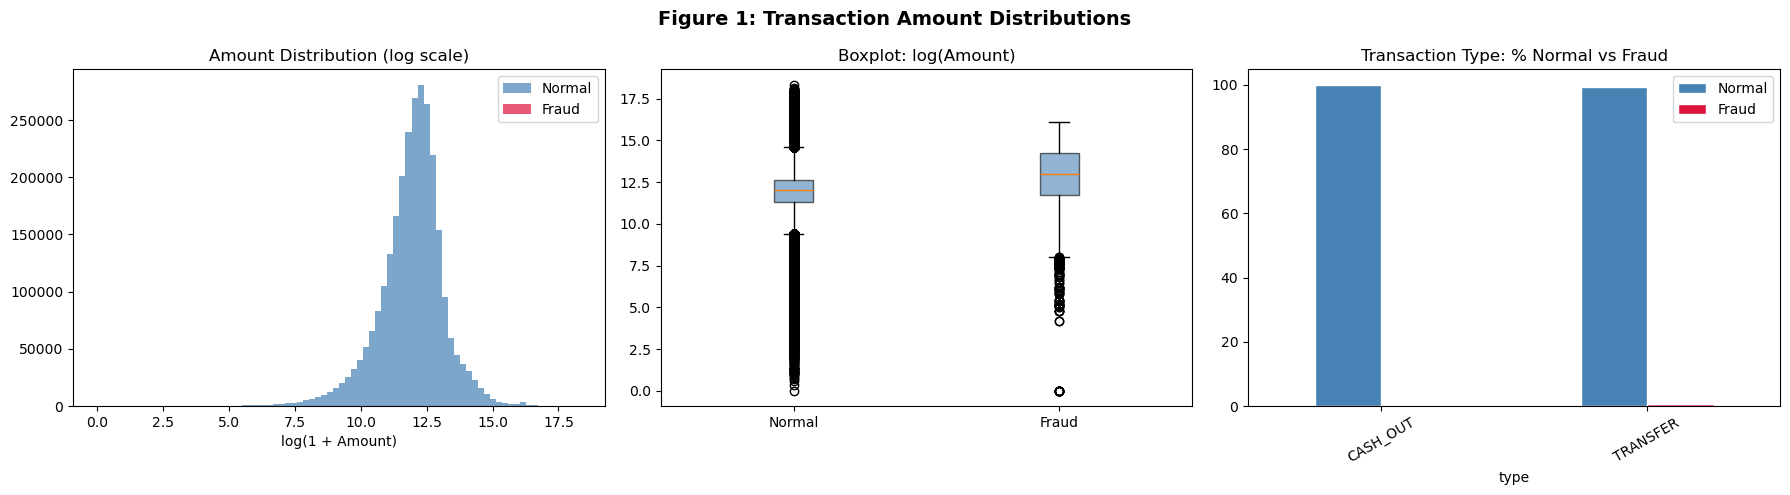

Figure 1 saved.


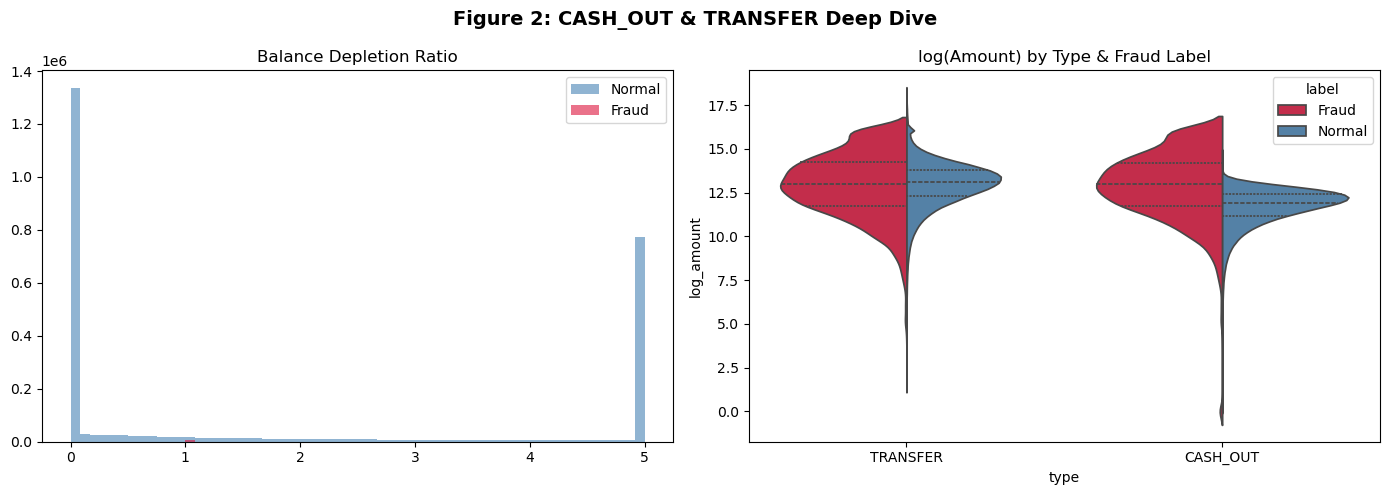

Figure 2 saved.


In [5]:
# ============================================================
# Summary Statistics + Figures 1-2
# ============================================================

print("=== DATA QUALITY CHECKS ===")
print(f"Negative amounts        : {(df['amount'] <= 0).sum()}")
print(f"Missing values          : {df.isnull().sum().sum()}")

print("\n=== SUMMARY STATISTICS ===")
print(df[['amount','oldbalanceOrg','newbalanceOrig',
          'oldbalanceDest','newbalanceDest']].describe().round(2))

print("\n=== FRAUD BY TRANSACTION TYPE ===")
fraud_by_type = df.groupby('type')['isFraud'].agg(
    ['sum','count','mean'])
fraud_by_type.columns = ['fraud_count','total','fraud_rate']
fraud_by_type['fraud_rate_pct'] = (
    fraud_by_type['fraud_rate']*100).round(4)
print(fraud_by_type.sort_values('fraud_count', ascending=False))

print("\n=== AMOUNT STATS: NORMAL vs FRAUD ===")
for label, group in df.groupby('isFraud'):
    tag = "FRAUD" if label==1 else "NORMAL"
    print(f"\n{tag} (n={len(group):,})")
    print(group['amount'].describe().round(2))

# Figure 1
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Figure 1: Transaction Amount Distributions',
             fontsize=14, fontweight='bold')
normal_amt = df[df['isFraud']==0]['amount']
fraud_amt  = df[df['isFraud']==1]['amount']
axes[0].hist(np.log1p(normal_amt), bins=80,
             color='steelblue', alpha=0.7, label='Normal')
axes[0].hist(np.log1p(fraud_amt),  bins=80,
             color='crimson', alpha=0.7, label='Fraud')
axes[0].set_title('Amount Distribution (log scale)')
axes[0].set_xlabel('log(1 + Amount)')
axes[0].legend()
axes[1].boxplot(
    [np.log1p(normal_amt), np.log1p(fraud_amt)],
    labels=['Normal','Fraud'], patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot: log(Amount)')
type_fraud = df.groupby(['type','isFraud']).size().unstack(fill_value=0)
type_fraud.columns = ['Normal','Fraud']
type_fraud.div(type_fraud.sum(axis=1), axis=0).mul(100).plot(
    kind='bar', ax=axes[2],
    color=['steelblue','crimson'], edgecolor='white')
axes[2].set_title('Transaction Type: % Normal vs Fraud')
axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('fig1_amount_distributions.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

# Figure 2
df_ct = df[df['type'].isin(['CASH_OUT','TRANSFER'])].copy()
df_ct['label']      = df_ct['isFraud'].map({0:'Normal',1:'Fraud'})
df_ct['log_amount'] = np.log1p(df_ct['amount'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 2: CASH_OUT & TRANSFER Deep Dive',
             fontsize=14, fontweight='bold')
for label, color, name in [(0,'steelblue','Normal'),
                            (1,'crimson','Fraud')]:
    subset = df_ct[df_ct['isFraud']==label][
        'balance_depletion_ratio']
    axes[0].hist(subset.clip(0,5), bins=60,
                 alpha=0.6, color=color, label=name)
axes[0].set_title('Balance Depletion Ratio')
axes[0].legend()
sns.violinplot(data=df_ct, x='type', y='log_amount',
               hue='label', split=True,
               palette={'Normal':'steelblue','Fraud':'crimson'},
               inner='quartile', ax=axes[1])
axes[1].set_title('log(Amount) by Type & Fraud Label')
plt.tight_layout()
plt.savefig('fig2_cashout_transfer.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

=== CORRELATION WITH isFraud (sorted) ===
oldbalanceOrg              0.348
zero_dest_balance          0.080
amount                     0.071
balance_error_dest         0.070
newbalanceOrig             0.064
balance_error_orig         0.017
balance_depletion_ratio   -0.002
newbalanceDest            -0.009
oldbalanceDest            -0.015
zero_orig_balance         -0.051
Name: isFraud, dtype: float64


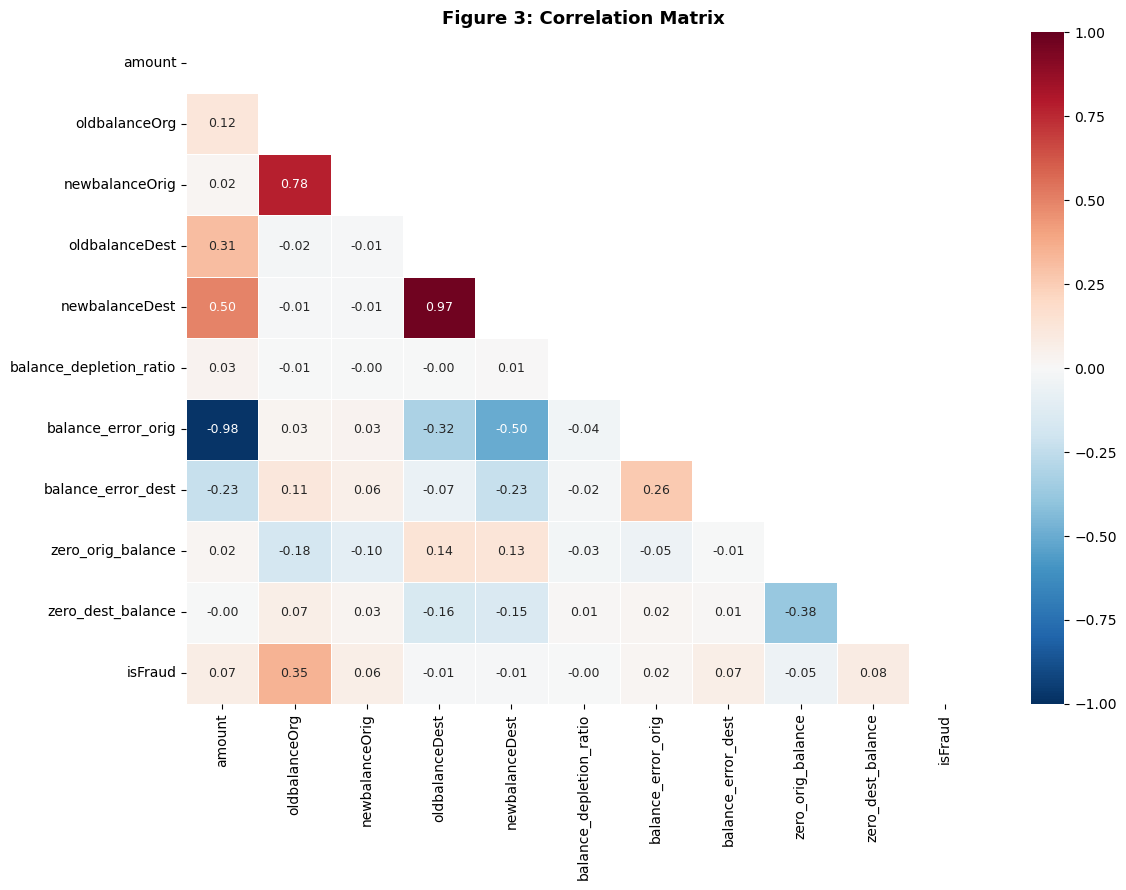

Figure 3 saved.


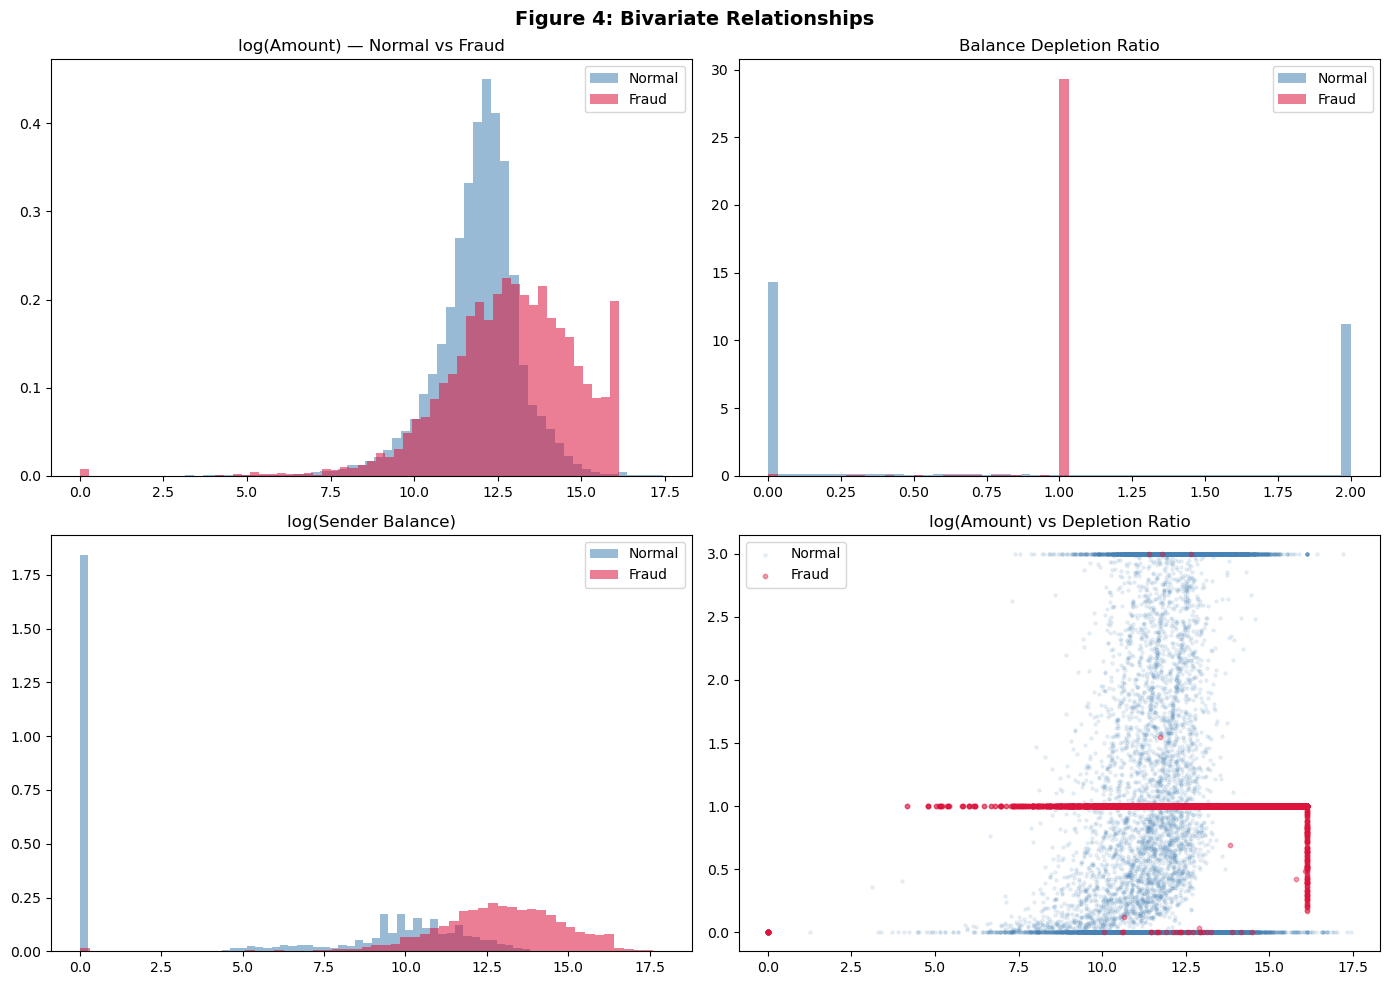

Figure 4 saved.


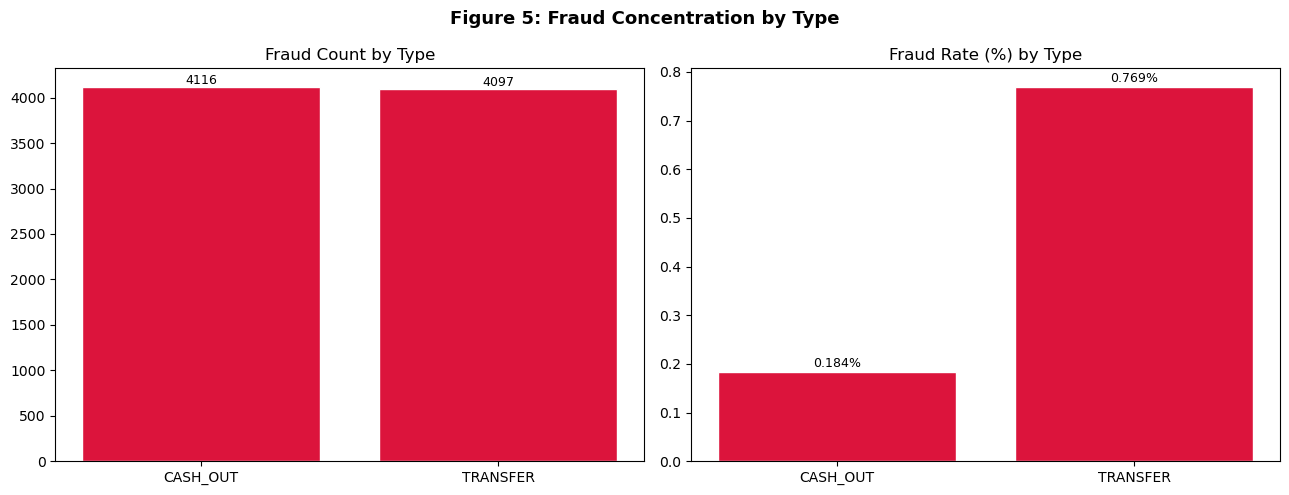

Figure 5 saved.


In [6]:
# ============================================================
#  Correlation + Bivariate Analysis + Figures 3-5
# ============================================================

corr_cols = ['amount','oldbalanceOrg','newbalanceOrig',
             'oldbalanceDest','newbalanceDest',
             'balance_depletion_ratio','balance_error_orig',
             'balance_error_dest','zero_orig_balance',
             'zero_dest_balance','isFraud']
corr_matrix = df[corr_cols].corr().round(3)

print("=== CORRELATION WITH isFraud (sorted) ===")
print(corr_matrix['isFraud'].drop('isFraud')
      .sort_values(ascending=False))

# Figure 3
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_matrix, mask=mask, annot=True,
            fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={"size":9})
ax.set_title('Figure 3: Correlation Matrix',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

# Figures 4-5 (bivariate + fraud by type)
np.random.seed(42)
normal_sample = df[df['isFraud']==0].sample(20000)
fraud_all     = df[df['isFraud']==1]
df_vis = pd.concat([normal_sample, fraud_all])
df_vis['label']      = df_vis['isFraud'].map({0:'Normal',1:'Fraud'})
df_vis['log_amount'] = np.log1p(df_vis['amount'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Figure 4: Bivariate Relationships',
             fontsize=14, fontweight='bold')
for label, color in [('Normal','steelblue'),('Fraud','crimson')]:
    s = df_vis[df_vis['label']==label]['log_amount']
    axes[0,0].hist(s, bins=60, alpha=0.55,
                   color=color, label=label, density=True)
axes[0,0].set_title('log(Amount) — Normal vs Fraud')
axes[0,0].legend()
for label, color in [('Normal','steelblue'),('Fraud','crimson')]:
    s = df_vis[df_vis['label']==label][
        'balance_depletion_ratio'].clip(0,2)
    axes[0,1].hist(s, bins=60, alpha=0.55,
                   color=color, label=label, density=True)
axes[0,1].set_title('Balance Depletion Ratio')
axes[0,1].legend()
for label, color in [('Normal','steelblue'),('Fraud','crimson')]:
    s = np.log1p(df_vis[df_vis['label']==label]['oldbalanceOrg'])
    axes[1,0].hist(s, bins=60, alpha=0.55,
                   color=color, label=label, density=True)
axes[1,0].set_title('log(Sender Balance)')
axes[1,0].legend()
axes[1,1].scatter(
    df_vis[df_vis['label']=='Normal']['log_amount'],
    df_vis[df_vis['label']=='Normal'][
        'balance_depletion_ratio'].clip(0,3),
    alpha=0.1, s=5, color='steelblue', label='Normal')
axes[1,1].scatter(
    df_vis[df_vis['label']=='Fraud']['log_amount'],
    df_vis[df_vis['label']=='Fraud'][
        'balance_depletion_ratio'].clip(0,3),
    alpha=0.4, s=10, color='crimson', label='Fraud')
axes[1,1].set_title('log(Amount) vs Depletion Ratio')
axes[1,1].legend()
plt.tight_layout()
plt.savefig('fig4_bivariate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

fraud_by_type2 = df.groupby('type')['isFraud'].agg(
    ['sum','count','mean'])
fraud_by_type2.columns = ['fraud_count','total','fraud_rate']
fraud_by_type2 = fraud_by_type2.sort_values(
    'fraud_count', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 5: Fraud Concentration by Type',
             fontsize=13, fontweight='bold')
colors5 = ['crimson' if t in ['CASH_OUT','TRANSFER']
           else 'steelblue' for t in fraud_by_type2.index]
axes[0].bar(fraud_by_type2.index,
            fraud_by_type2['fraud_count'],
            color=colors5, edgecolor='white')
axes[0].set_title('Fraud Count by Type')
for i,(idx,row) in enumerate(fraud_by_type2.iterrows()):
    axes[0].text(i, row['fraud_count']+30,
                 str(int(row['fraud_count'])),
                 ha='center', fontsize=9)
axes[1].bar(fraud_by_type2.index,
            fraud_by_type2['fraud_rate']*100,
            color=colors5, edgecolor='white')
axes[1].set_title('Fraud Rate (%) by Type')
for i,(idx,row) in enumerate(fraud_by_type2.iterrows()):
    axes[1].text(i, row['fraud_rate']*100+0.01,
                 f"{row['fraud_rate']*100:.3f}%",
                 ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig5_fraud_by_type.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Figure 5 saved.")

=== IQR OUTLIER DETECTION (Layer 1 of 3) ===

Feature: amount
  Total outliers   : 223,100 (8.05%)
  Fraud in outliers: 3,443 / 8,213 (41.9%)

Feature: oldbalanceOrg
  Total outliers   : 395,573 (14.28%)
  Fraud in outliers: 6,753 / 8,213 (82.2%)

Feature: newbalanceOrig
  Total outliers   : 273,753 (9.88%)
  Fraud in outliers: 160 / 8,213 (1.9%)

Feature: oldbalanceDest
  Total outliers   : 286,491 (10.34%)
  Fraud in outliers: 254 / 8,213 (3.1%)

Feature: newbalanceDest
  Total outliers   : 276,087 (9.97%)
  Fraud in outliers: 670 / 8,213 (8.2%)

Feature: balance_depletion_ratio
  Total outliers   : 444,721 (16.05%)
  Fraud in outliers: 2 / 8,213 (0.0%)

Crosstab — IQR Outlier vs isFraud:
isFraud            0     1
IQR Outlier               
0            1414221  3062
1            1347975  5151

Fraud caught by IQR : 5,151 / 8,213 = 62.7%
Precision of IQR    : 0.381%


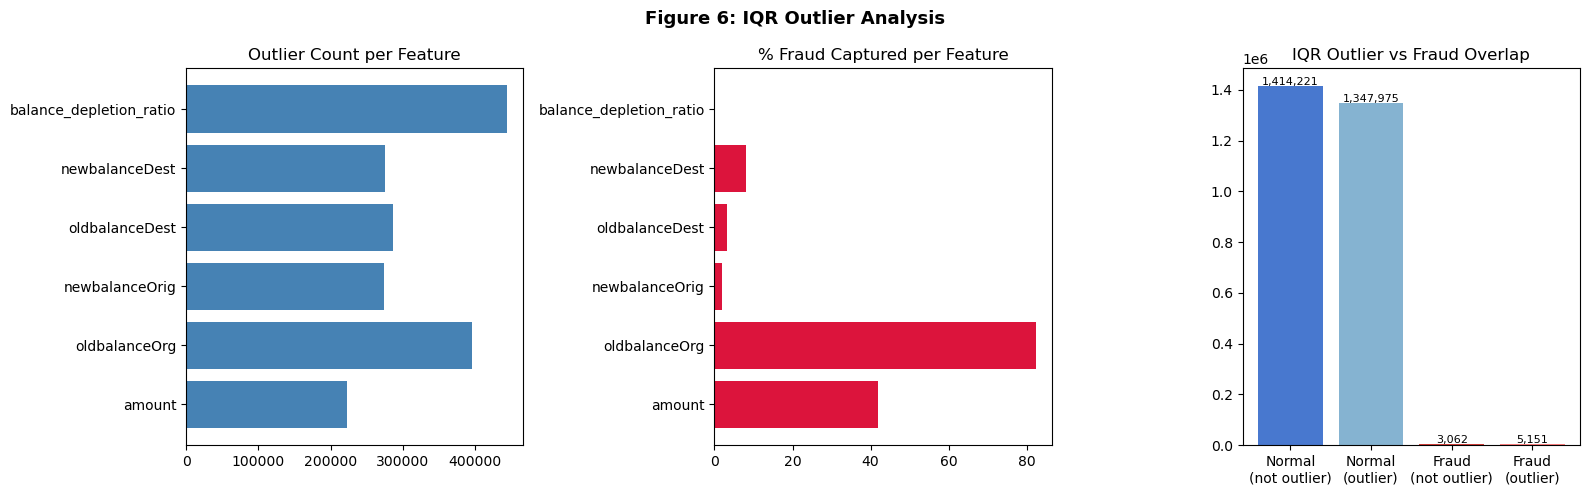

Figure 6 saved.


In [7]:
# ============================================================
# IQR Outlier Analysis + Figure 6
# ============================================================

print("=== IQR OUTLIER DETECTION (Layer 1 of 3) ===\n")
outlier_results = {}
for col in outlier_features:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    is_outlier = (df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)
    outlier_results[col] = is_outlier
    total   = is_outlier.sum()
    f_caught = df[is_outlier]['isFraud'].sum()
    print(f"Feature: {col}")
    print(f"  Total outliers   : {total:,} "
          f"({total/len(df)*100:.2f}%)")
    print(f"  Fraud in outliers: {f_caught:,} / "
          f"{df['isFraud'].sum():,} "
          f"({f_caught/df['isFraud'].sum()*100:.1f}%)\n")

ct = pd.crosstab(df['iqr_outlier'], df['isFraud'],
                 rownames=['IQR Outlier'],
                 colnames=['isFraud'])
print("Crosstab — IQR Outlier vs isFraud:")
print(ct)
fraud_caught = ct.loc[1,1] if 1 in ct.index else 0
print(f"\nFraud caught by IQR : "
      f"{fraud_caught:,} / {df['isFraud'].sum():,} "
      f"= {fraud_caught/df['isFraud'].sum()*100:.1f}%")
print(f"Precision of IQR    : "
      f"{fraud_caught/df['iqr_outlier'].sum()*100:.3f}%")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 6: IQR Outlier Analysis',
             fontsize=13, fontweight='bold')
outlier_counts = {col: v.sum()
                  for col,v in outlier_results.items()}
axes[0].barh(list(outlier_counts.keys()),
             list(outlier_counts.values()),
             color='steelblue')
axes[0].set_title('Outlier Count per Feature')
fraud_pct = {col: df[v]['isFraud'].sum()/df['isFraud'].sum()*100
             for col,v in outlier_results.items()}
axes[1].barh(list(fraud_pct.keys()),
             list(fraud_pct.values()),
             color='crimson')
axes[1].set_title('% Fraud Captured per Feature')
sizes = [
    ((df['iqr_outlier']==0)&(df['isFraud']==0)).sum(),
    ((df['iqr_outlier']==1)&(df['isFraud']==0)).sum(),
    ((df['iqr_outlier']==0)&(df['isFraud']==1)).sum(),
    ((df['iqr_outlier']==1)&(df['isFraud']==1)).sum(),
]
axes[2].bar(['Normal\n(not outlier)','Normal\n(outlier)',
             'Fraud\n(not outlier)','Fraud\n(outlier)'],
            sizes,
            color=['#4878CF','#85B3D1','#D43F3A','#FF7F7F'])
axes[2].set_title('IQR Outlier vs Fraud Overlap')
for i,v in enumerate(sizes):
    axes[2].text(i, v+5000, f'{v:,}',
                 ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('fig6_iqr_outliers.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Figure 6 saved.")

MANN-WHITNEY U TESTS + EFFECT SIZES

Bonferroni-corrected alpha: 0.05 / 6 = 0.0083


amount
  Median Normal:      171,034.46
  Median Fraud :      441,423.44
  p-value      : 0.0000e+00
  Effect size  : -0.3667 (medium)
  Decision     : SIGNIFICANT after Bonferroni

oldbalanceOrg
  Median Normal:          283.00
  Median Fraud :      438,983.45
  p-value      : 0.0000e+00
  Effect size  : -0.8553 (large)
  Decision     : SIGNIFICANT after Bonferroni

balance_depletion_ratio
  Median Normal:            0.22
  Median Fraud :            1.00
  p-value      : 6.3758e-121
  Effect size  : -0.1411 (small)
  Decision     : SIGNIFICANT after Bonferroni

oldbalanceDest
  Median Normal:      558,272.99
  Median Fraud :            0.00
  p-value      : 0.0000e+00
  Effect size  : 0.5718 (large)
  Decision     : SIGNIFICANT after Bonferroni

newbalanceDest
  Median Normal:      829,902.93
  Median Fraud :        4,676.42
  p-value      : 0.0000e+00
  Effect size  : 0.4533 (medium)
  Decision     :

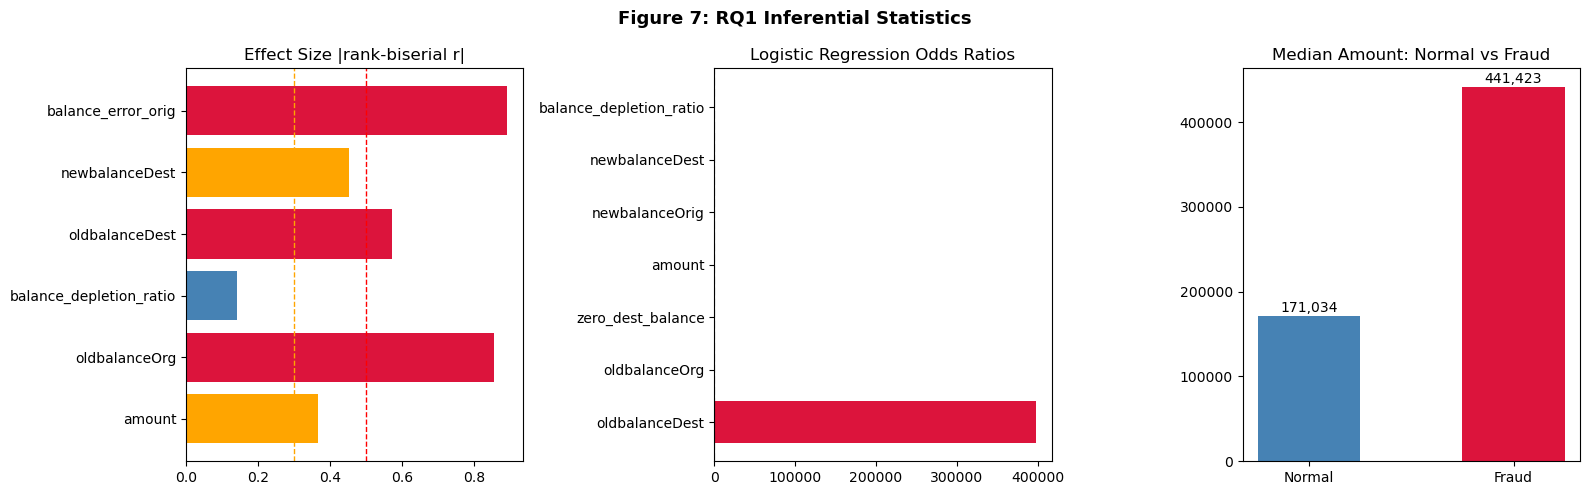

Figure 7 saved.


In [8]:
# ============================================================
#INFERENTIAL STATISTICS (RQ1) + FIGURE 7
# ============================================================
fraud  = df[df['isFraud']==1]
normal = df[df['isFraud']==0]

print("=" * 60)
print("MANN-WHITNEY U TESTS + EFFECT SIZES")
print("=" * 60)
test_features = ['amount','oldbalanceOrg',
                 'balance_depletion_ratio',
                 'oldbalanceDest','newbalanceDest',
                 'balance_error_orig']

# ← NEW: Bonferroni correction
alpha_raw        = 0.05
alpha_bonferroni = alpha_raw / len(test_features)   # = 0.0083
print(f"\nBonferroni-corrected alpha: "
      f"{alpha_raw} / {len(test_features)} = {alpha_bonferroni:.4f}\n")

for col in test_features:
    fv = fraud[col].dropna()
    nv = normal[col].dropna()
    u_stat, p_val = mannwhitneyu(fv, nv, alternative='two-sided')
    n1, n2 = len(fv), len(nv)
    r_rb   = 1 - (2*u_stat)/(n1*n2)
    size   = ('large'  if abs(r_rb) > 0.5
              else 'medium' if abs(r_rb) > 0.3 else 'small')
    # ← NEW: decision after Bonferroni
    sig = ("SIGNIFICANT after Bonferroni"
           if p_val < alpha_bonferroni
           else "NOT significant after Bonferroni")
    print(f"\n{col}")
    print(f"  Median Normal: {nv.median():>15,.2f}")
    print(f"  Median Fraud : {fv.median():>15,.2f}")
    print(f"  p-value      : {p_val:.4e}")
    print(f"  Effect size  : {r_rb:.4f} ({size})")
    print(f"  Decision     : {sig}")

print("\n" + "="*60)
print("CHI-SQUARE TEST")
print("="*60)
contingency = pd.crosstab(df['type'], df['isFraud'])
chi2, p_chi, dof, _ = chi2_contingency(contingency)
n = contingency.values.sum()
cramers_v = np.sqrt(chi2/(n*(min(contingency.shape)-1)))
print(f"Chi-square: {chi2:.2f}, p={p_chi:.4e}")
print(f"Cramer's V: {cramers_v:.4f}")

print("\n" + "="*60)
print("LOGISTIC REGRESSION")
print("="*60)
df_lr       = df.copy()
lr_features = ['amount','oldbalanceOrg','newbalanceOrig',
                'oldbalanceDest','newbalanceDest',
                'balance_depletion_ratio','zero_dest_balance']
X = df_lr[lr_features].copy()
y = df_lr['isFraud'].copy()
for col in lr_features[:-1]:
    X[col] = X[col].clip(upper=X[col].quantile(0.999))
scaler_lr = StandardScaler()
X_scaled  = scaler_lr.fit_transform(X)
lr = LogisticRegression(class_weight='balanced',
                        max_iter=1000, random_state=42)
lr.fit(X_scaled, y)
coef_df = pd.DataFrame({
    'feature'    : lr_features,
    'coefficient': lr.coef_[0],
    'odds_ratio' : np.exp(lr.coef_[0])
}).sort_values('coefficient', ascending=False)
print(coef_df.round(4).to_string(index=False))
y_prob = lr.predict_proba(X_scaled)[:,1]
print(f"\nROC-AUC: {roc_auc_score(y, y_prob):.4f}")

# Figure 7
effect_sizes = {}
for col in test_features:
    u,_ = mannwhitneyu(fraud[col], normal[col], alternative='two-sided')
    n1,n2 = len(fraud[col]), len(normal[col])
    effect_sizes[col] = abs(1-(2*u)/(n1*n2))
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 7: RQ1 Inferential Statistics',
             fontsize=13, fontweight='bold')
colors_es = ['crimson' if v>0.5 else 'orange' if v>0.3
             else 'steelblue' for v in effect_sizes.values()]
axes[0].barh(list(effect_sizes.keys()), list(effect_sizes.values()),
             color=colors_es)
axes[0].axvline(0.5, color='red',    linestyle='--', linewidth=1)
axes[0].axvline(0.3, color='orange', linestyle='--', linewidth=1)
axes[0].set_title('Effect Size |rank-biserial r|')
axes[1].barh(coef_df['feature'], coef_df['odds_ratio'],
             color=['crimson' if x>1 else 'steelblue'
                    for x in coef_df['odds_ratio']])
axes[1].axvline(1.0, color='black', linestyle='--')
axes[1].set_title('Logistic Regression Odds Ratios')
medians = pd.DataFrame({
    'Group' : ['Normal','Fraud'],
    'Median': [normal['amount'].median(), fraud['amount'].median()]
})
axes[2].bar(medians['Group'], medians['Median'],
            color=['steelblue','crimson'], width=0.5)
axes[2].set_title('Median Amount: Normal vs Fraud')
for i,row in medians.iterrows():
    axes[2].text(i, row['Median']+5000,
                 f"{row['Median']:,.0f}", ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('fig7_inferential.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 7 saved.")

Running IF tuning grid (sensitivity analysis)...

=== IF TUNING RESULTS (top 10 by F1) ===
 n_estimators max_samples  contamination  flagged_pct  precision  recall     f1  roc_auc
           50         512          0.010        1.000     0.0647  0.2183 0.0998   0.8639
          100         512          0.010        1.000     0.0605  0.2042 0.0934   0.8694
          200         512          0.010        1.000     0.0567  0.1912 0.0874   0.8684
           50         512          0.005        0.500     0.0642  0.1084 0.0807   0.8639
           50         512          0.003        0.299     0.0681  0.0687 0.0684   0.8639
          100         512          0.005        0.500     0.0532  0.0897 0.0668   0.8694
           50        auto          0.010        1.000     0.0421  0.1418 0.0649   0.8579
           50         256          0.010        1.000     0.0421  0.1418 0.0649   0.8579
          100        auto          0.010        1.000     0.0337  0.1137 0.0520   0.8623
          100      

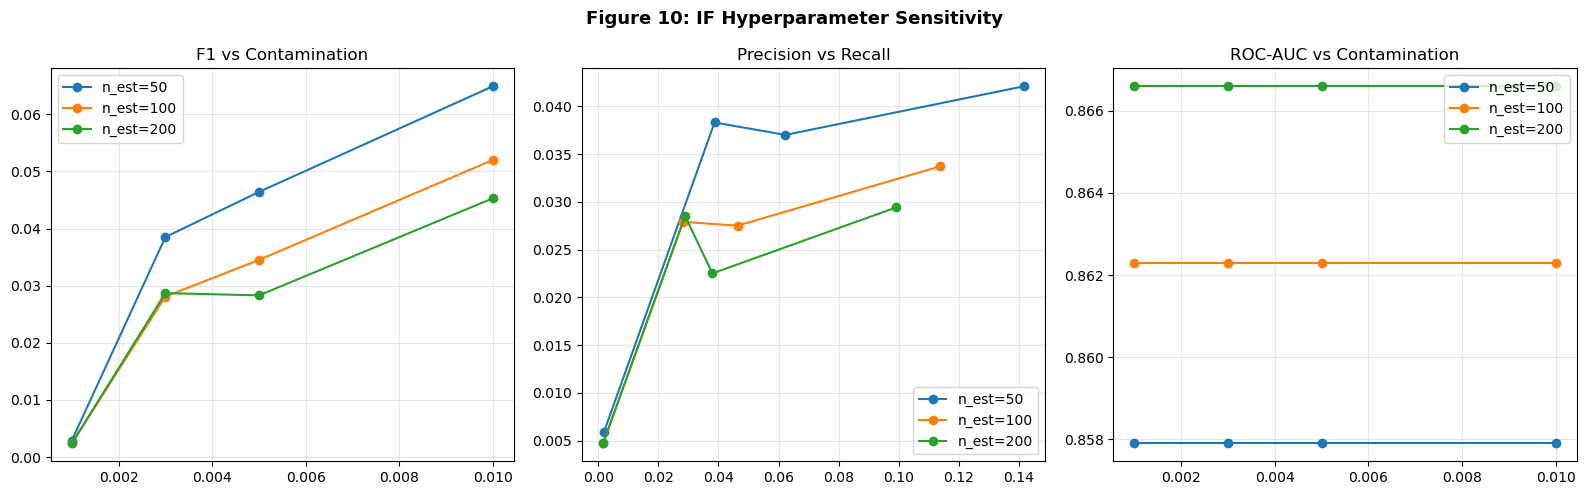

Figure 10 saved.


In [9]:
# ============================================================
# ISOLATION FOREST TUNING + FIGURE 10
# NOTE: Grid is SENSITIVITY ANALYSIS only.
#       Pre-specified value contamination=0.003 is used later2.
# ============================================================
df_if = df.copy()
if_features = ['amount','oldbalanceOrg','newbalanceOrig',
               'oldbalanceDest','newbalanceDest',
               'balance_depletion_ratio',
               'balance_error_orig','zero_dest_balance']
X_if = df_if[if_features].copy()
for col in if_features[:-1]:
    X_if[col] = X_if[col].clip(upper=X_if[col].quantile(0.999))
y_true = df_if['isFraud'].values

param_grid = {
    'n_estimators' : [50, 100, 200],
    'max_samples'  : [256, 512, 'auto'],
    'contamination': [0.001, 0.003, 0.005, 0.01],
}
results = []
print("Running IF tuning grid (sensitivity analysis)...")
for contamination in param_grid['contamination']:
    for n_est in param_grid['n_estimators']:
        for max_samp in param_grid['max_samples']:
            iso = IsolationForest(
                n_estimators=n_est, max_samples=max_samp,
                contamination=contamination, max_features=1.0,
                random_state=42, n_jobs=-1)
            iso.fit(X_if)
            y_pred  = (iso.predict(X_if)==-1).astype(int)
            y_score = -iso.score_samples(X_if)
            results.append({
                'n_estimators' : n_est,
                'max_samples'  : max_samp,
                'contamination': contamination,
                'flagged_pct'  : round(y_pred.mean()*100,3),
                'precision'    : round(precision_score(y_true,y_pred,zero_division=0),4),
                'recall'       : round(recall_score(y_true,y_pred,zero_division=0),4),
                'f1'           : round(f1_score(y_true,y_pred,zero_division=0),4),
                'roc_auc'      : round(roc_auc_score(y_true,y_score),4),
            })
results_df = pd.DataFrame(results)
print("\n=== IF TUNING RESULTS (top 10 by F1) ===")
print(results_df.sort_values('f1',ascending=False).head(10).to_string(index=False))
best_row = results_df.loc[results_df['f1'].idxmax()]
print(f"\nBest (sensitivity): n_est={best_row['n_estimators']}, "
      f"contamination={best_row['contamination']}, F1={best_row['f1']}")

# Figure 10
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 10: IF Hyperparameter Sensitivity',
             fontsize=13, fontweight='bold')
for n_est in [50,100,200]:
    s = results_df[(results_df['n_estimators']==n_est) &
                   (results_df['max_samples']=='auto')]
    axes[0].plot(s['contamination'], s['f1'], marker='o', label=f'n_est={n_est}')
axes[0].set_title('F1 vs Contamination')
axes[0].legend()
axes[0].grid(alpha=0.3)
for n_est in [50,100,200]:
    s = results_df[(results_df['n_estimators']==n_est) &
                   (results_df['max_samples']=='auto')]
    axes[1].plot(s['recall'], s['precision'], marker='o', label=f'n_est={n_est}')
axes[1].set_title('Precision vs Recall')
axes[1].legend()
axes[1].grid(alpha=0.3)
for n_est in [50,100,200]:
    s = results_df[(results_df['n_estimators']==n_est) &
                   (results_df['max_samples']=='auto')]
    axes[2].plot(s['contamination'], s['roc_auc'], marker='o', label=f'n_est={n_est}')
axes[2].set_title('ROC-AUC vs Contamination')
axes[2].legend()
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig10_if_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 10 saved.")

In [10]:
# ============================================================
# Save best IF predictions back to df_if
# ============================================================

# Refit best IF and save predictions to df_if
best_iso = IsolationForest(
    n_estimators  = int(best_row['n_estimators']),
    max_samples   = best_row['max_samples'],
    contamination = best_row['contamination'],
    max_features  = 1.0,
    random_state  = 42,
    n_jobs        = -1
)
best_iso.fit(X_if)

df_if['if_anomaly'] = (
    best_iso.predict(X_if) == -1).astype(int)
df_if['if_score']   = -best_iso.score_samples(X_if)

print(f"\nIF predictions saved to df_if:")
print(f"  if_anomaly flagged : {df_if['if_anomaly'].sum():,}")
print(f"  if_score range     : "
      f"{df_if['if_score'].min():.4f} → "
      f"{df_if['if_score'].max():.4f}")
print(f"  Columns in df_if   : {df_if.columns.tolist()}")


IF predictions saved to df_if:
  if_anomaly flagged : 27,702
  if_score range     : 0.3194 → 0.8433
  Columns in df_if   : ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'balance_depletion_ratio', 'balance_error_orig', 'balance_error_dest', 'zero_orig_balance', 'zero_dest_balance', 'iqr_outlier', 'if_anomaly', 'if_score']


LOF sample: 278,213 (fraud=8,213, 2.95%)
Normal sample = 270,000 (was 100,000) — fraud rate ~3% (was 7.59%)

Running LOF tuning...

Best LOF: n_neighbors=50, contamination=0.01, metric=manhattan
F1=0.0264, AUC=0.5132

LOF Score — Normal median: 1.0089 | Fraud median: 1.0129


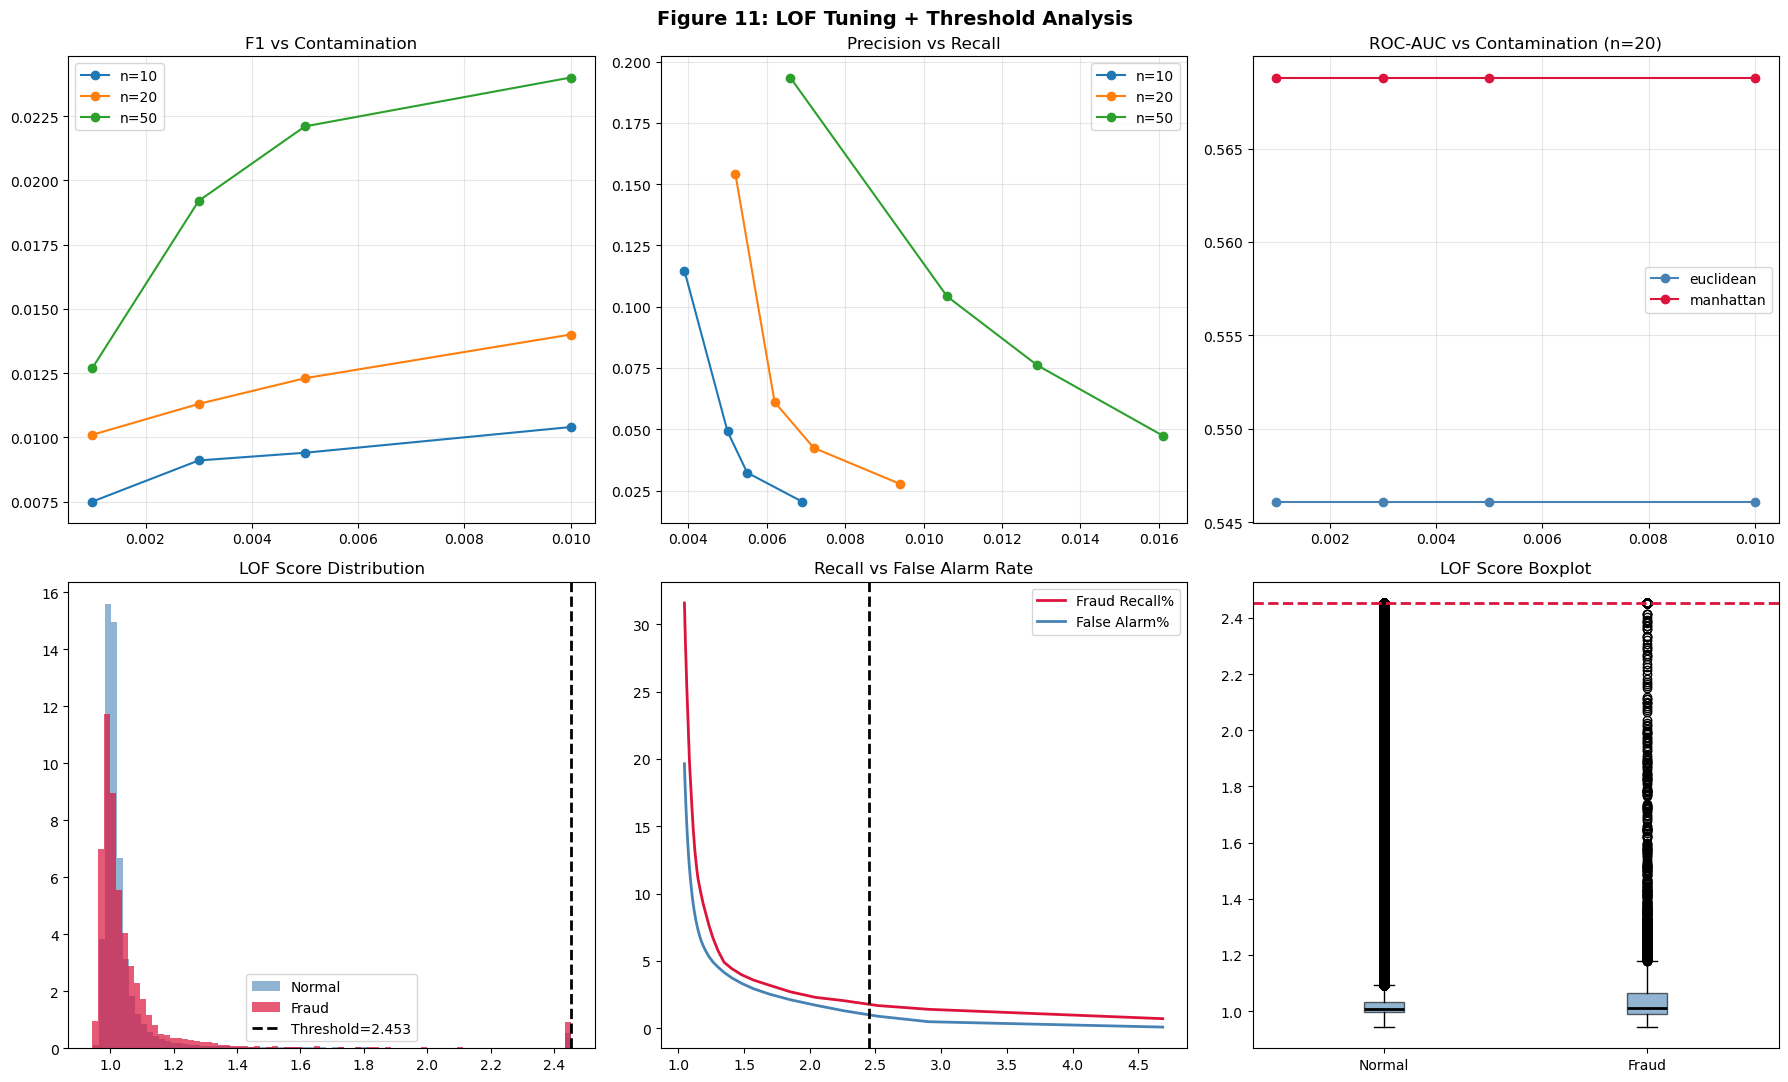

Figure 11 saved.


In [11]:
# ============================================================
# LOF TUNING + FIGURE 11
# ============================================================
np.random.seed(42)
fraud_idx  = df_if[df_if['isFraud']==1].index
normal_idx = df_if[df_if['isFraud']==0].sample(
    n=270000, random_state=42).index          # ← CHANGED from 100000
sample_idx = fraud_idx.union(normal_idx)
df_lof     = df_if.loc[sample_idx].copy()

X_lof = df_lof[if_features].copy()
for col in if_features[:-1]:
    X_lof[col] = X_lof[col].clip(upper=X_lof[col].quantile(0.999))
y_lof = df_lof['isFraud'].values

scaler_lof   = RobustScaler()
X_lof_scaled = scaler_lof.fit_transform(X_lof)

print(f"LOF sample: {len(X_lof):,} "
      f"(fraud={y_lof.sum():,}, {y_lof.mean()*100:.2f}%)")
print("Normal sample = 270,000 (was 100,000) — fraud rate ~3% (was 7.59%)")

lof_params = {
    'n_neighbors'  : [10, 20, 50],
    'contamination': [0.001, 0.003, 0.005, 0.01],
    'metric'       : ['euclidean', 'manhattan']
}
lof_results = []
print("\nRunning LOF tuning...")
for n_neigh in lof_params['n_neighbors']:
    for contam in lof_params['contamination']:
        for metric in lof_params['metric']:
            lof = LocalOutlierFactor(
                n_neighbors=n_neigh, contamination=contam,
                metric=metric, n_jobs=-1, novelty=False)
            y_pred     = (lof.fit_predict(X_lof_scaled)==-1).astype(int)
            lof_scores = -lof.negative_outlier_factor_
            lof_results.append({
                'n_neighbors'  : n_neigh,
                'contamination': contam,
                'metric'       : metric,
                'flagged_pct'  : round(y_pred.mean()*100,3),
                'precision'    : round(precision_score(y_lof,y_pred,zero_division=0),4),
                'recall'       : round(recall_score(y_lof,y_pred,zero_division=0),4),
                'f1'           : round(f1_score(y_lof,y_pred,zero_division=0),4),
                'roc_auc'      : round(roc_auc_score(y_lof,lof_scores),4),
            })

lof_results_df = pd.DataFrame(lof_results)
best_lof = lof_results_df.loc[lof_results_df['f1'].idxmax()]
print(f"\nBest LOF: n_neighbors={best_lof['n_neighbors']}, "
      f"contamination={best_lof['contamination']}, metric={best_lof['metric']}")
print(f"F1={best_lof['f1']}, AUC={best_lof['roc_auc']}")

best_lof_model = LocalOutlierFactor(
    n_neighbors=int(best_lof['n_neighbors']),
    contamination=best_lof['contamination'],
    metric=best_lof['metric'], n_jobs=-1, novelty=False)
best_lof_model.fit_predict(X_lof_scaled)
best_lof_scores = -best_lof_model.negative_outlier_factor_
best_lof_thresh = np.percentile(best_lof_scores, 100*(1-best_lof['contamination']))
print(f"\nLOF Score — Normal median: {np.median(best_lof_scores[y_lof==0]):.4f} "
      f"| Fraud median: {np.median(best_lof_scores[y_lof==1]):.4f}")

# Figure 11
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Figure 11: LOF Tuning + Threshold Analysis',
             fontsize=14, fontweight='bold')
for n_neigh in [10,20,50]:
    s = lof_results_df[(lof_results_df['n_neighbors']==n_neigh)&
                       (lof_results_df['metric']=='euclidean')]
    axes[0,0].plot(s['contamination'], s['f1'], marker='o', label=f'n={n_neigh}')
axes[0,0].set_title('F1 vs Contamination')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)
for n_neigh in [10,20,50]:
    s = lof_results_df[(lof_results_df['n_neighbors']==n_neigh)&
                       (lof_results_df['metric']=='euclidean')]
    axes[0,1].plot(s['recall'], s['precision'], marker='o', label=f'n={n_neigh}')
axes[0,1].set_title('Precision vs Recall')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)
for metric,color in [('euclidean','steelblue'),('manhattan','crimson')]:
    s = lof_results_df[(lof_results_df['metric']==metric)&
                       (lof_results_df['n_neighbors']==20)]
    axes[0,2].plot(s['contamination'], s['roc_auc'], marker='o', color=color, label=metric)
axes[0,2].set_title('ROC-AUC vs Contamination (n=20)')
axes[0,2].legend(); axes[0,2].grid(alpha=0.3)
clip_val = np.percentile(best_lof_scores, 99)
axes[1,0].hist(np.clip(best_lof_scores[y_lof==0],0,clip_val), bins=80,
               alpha=0.6, color='steelblue', density=True, label='Normal')
axes[1,0].hist(np.clip(best_lof_scores[y_lof==1],0,clip_val), bins=80,
               alpha=0.7, color='crimson', density=True, label='Fraud')
axes[1,0].axvline(min(best_lof_thresh,clip_val), color='black',
                   linestyle='--', linewidth=2, label=f'Threshold={best_lof_thresh:.3f}')
axes[1,0].set_title('LOF Score Distribution'); axes[1,0].legend()
thresholds = np.percentile(best_lof_scores, np.linspace(80,99.9,50))
axes[1,1].plot(thresholds,
               [(best_lof_scores[y_lof==1]>t).mean()*100 for t in thresholds],
               color='crimson', linewidth=2, label='Fraud Recall%')
axes[1,1].plot(thresholds,
               [(best_lof_scores[y_lof==0]>t).mean()*100 for t in thresholds],
               color='steelblue', linewidth=2, label='False Alarm%')
axes[1,1].axvline(best_lof_thresh, color='black', linestyle='--', linewidth=2)
axes[1,1].set_title('Recall vs False Alarm Rate'); axes[1,1].legend()
axes[1,2].boxplot(
    [np.clip(best_lof_scores[y_lof==0],0,clip_val),
     np.clip(best_lof_scores[y_lof==1],0,clip_val)],
    labels=['Normal','Fraud'], patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='black', linewidth=2))
axes[1,2].axhline(best_lof_thresh, color='crimson', linestyle='--', linewidth=2)
axes[1,2].set_title('LOF Score Boxplot')
plt.tight_layout()
plt.savefig('fig11_lof_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 11 saved.")

Running OCSVM tuning grid...
  kernel=rbf, nu=0.001, gamma=scale  → F1=0.0678, AUC=0.4632
  kernel=rbf, nu=0.001, gamma=auto   → F1=0.0826, AUC=0.8215
  kernel=rbf, nu=0.001, gamma=0.001  → F1=0.0492, AUC=0.4627
  kernel=rbf, nu=0.001, gamma=0.01   → F1=0.1168, AUC=0.7672
  kernel=rbf, nu=0.003, gamma=scale  → F1=0.0306, AUC=0.4374
  kernel=rbf, nu=0.003, gamma=auto   → F1=0.1153, AUC=0.8401
  kernel=rbf, nu=0.003, gamma=0.001  → F1=0.0600, AUC=0.5287
  kernel=rbf, nu=0.003, gamma=0.01   → F1=0.0674, AUC=0.7018
  kernel=rbf, nu=0.005, gamma=scale  → F1=0.0355, AUC=0.4243
  kernel=rbf, nu=0.005, gamma=auto   → F1=0.1284, AUC=0.8434
  kernel=rbf, nu=0.005, gamma=0.001  → F1=0.0447, AUC=0.5428
  kernel=rbf, nu=0.005, gamma=0.01   → F1=0.1266, AUC=0.7300
  kernel=rbf, nu=0.01, gamma=scale  → F1=0.0539, AUC=0.4175
  kernel=rbf, nu=0.01, gamma=auto   → F1=0.1574, AUC=0.8498
  kernel=rbf, nu=0.01, gamma=0.001  → F1=0.0432, AUC=0.5372
  kernel=rbf, nu=0.01, gamma=0.01   → F1=0.0805, AUC=0.7488

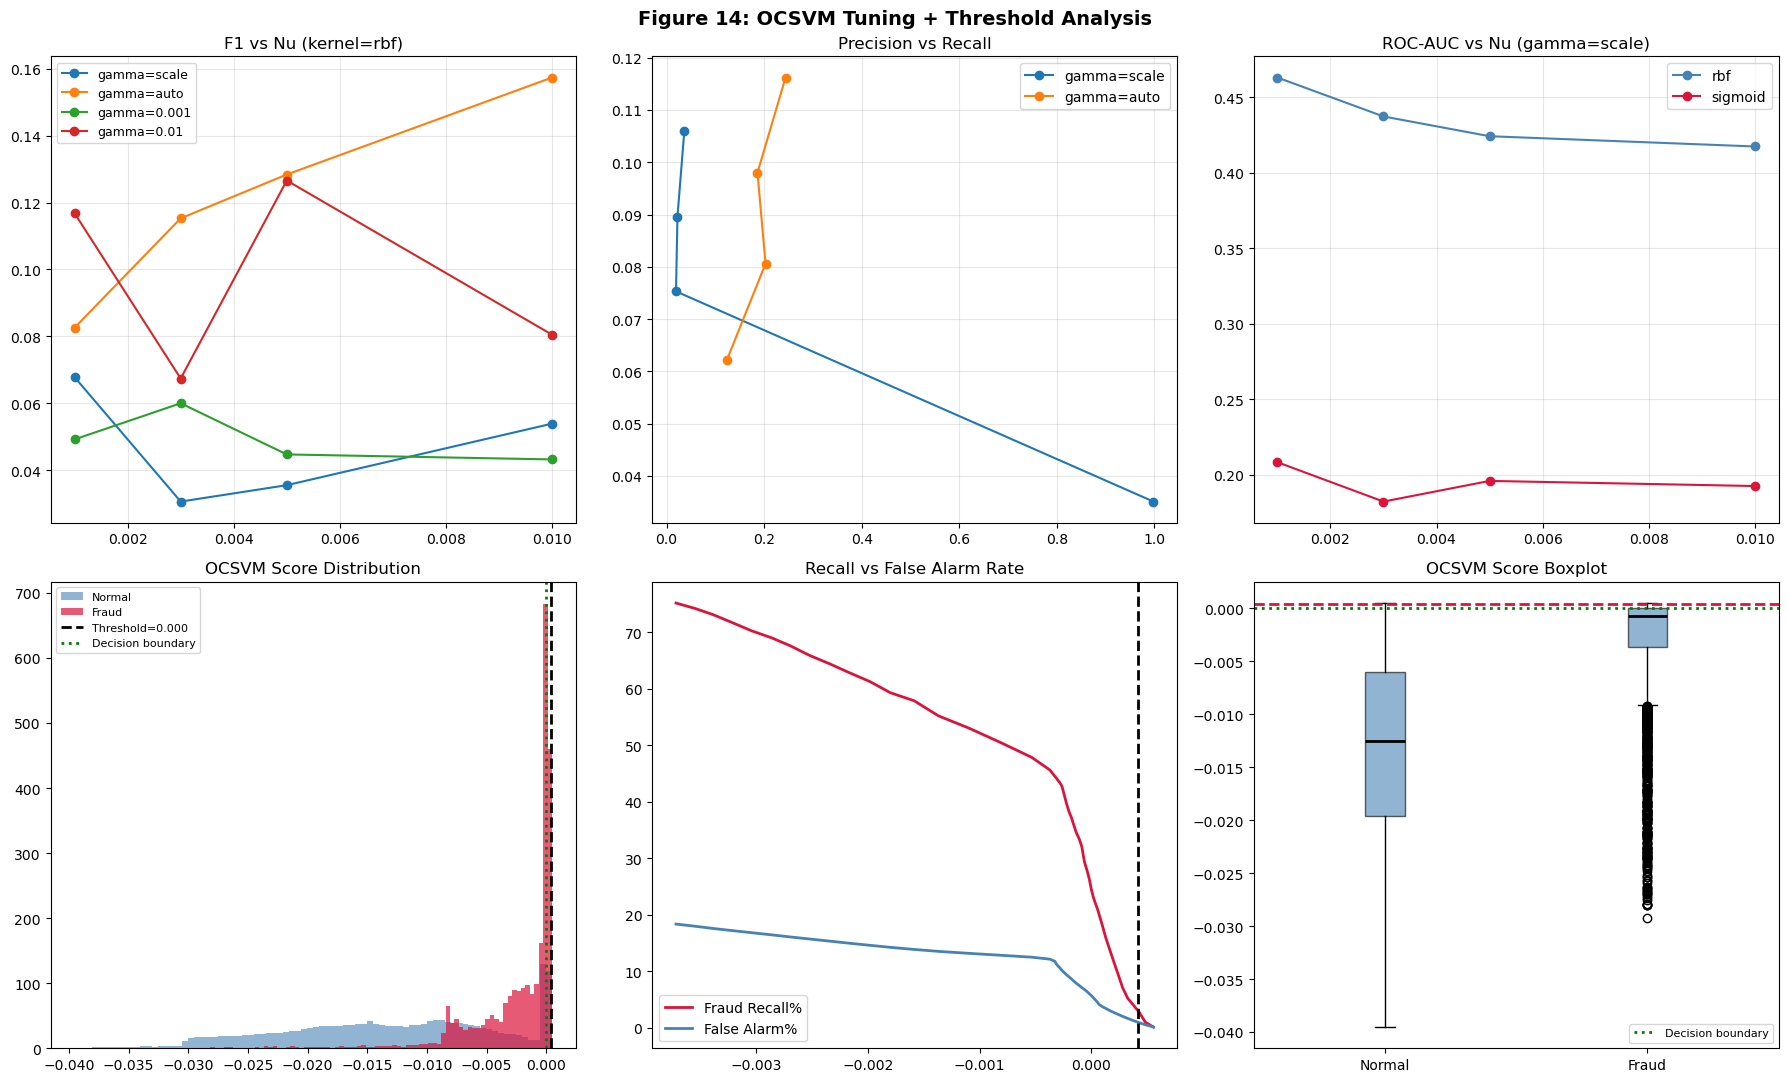

Figure 14 saved.


In [12]:
# ============================================================
# OCSVM Tuning + Figure 14
# ============================================================

scaler_ocsvm  = RobustScaler()
X_ocsvm_scaled = scaler_ocsvm.fit_transform(X_lof)

ocsvm_results = []
print("Running OCSVM tuning grid...")
for kernel in ['rbf','sigmoid']:
    for nu in [0.001,0.003,0.005,0.01]:
        for gamma in ['scale','auto',0.001,0.01]:
            ocsvm = OneClassSVM(nu=nu, gamma=gamma, kernel=kernel)
            ocsvm.fit(X_ocsvm_scaled)
            y_pred  = (ocsvm.predict(
                X_ocsvm_scaled)==-1).astype(int)
            scores  = -ocsvm.decision_function(X_ocsvm_scaled)
            try:
                auc = roc_auc_score(y_lof, scores)
            except:
                auc = 0.0
            ocsvm_results.append({
                'kernel'     : kernel,
                'nu'         : nu,
                'gamma'      : str(gamma),
                'threshold'  : round(np.percentile(
                    scores,100*(1-nu)),4),
                'flagged_pct': round(y_pred.mean()*100,3),
                'precision'  : round(precision_score(
                    y_lof,y_pred,zero_division=0),4),
                'recall'     : round(recall_score(
                    y_lof,y_pred,zero_division=0),4),
                'f1'         : round(f1_score(
                    y_lof,y_pred,zero_division=0),4),
                'roc_auc'    : round(auc,4),
            })
            print(f"  kernel={kernel}, nu={nu}, "
                  f"gamma={str(gamma):<6} → "
                  f"F1={ocsvm_results[-1]['f1']:.4f}, "
                  f"AUC={auc:.4f}")

ocsvm_results_df = pd.DataFrame(ocsvm_results)
best_ocsvm = ocsvm_results_df.loc[
    ocsvm_results_df['f1'].idxmax()]
print(f"\nBest OCSVM: kernel={best_ocsvm['kernel']}, "
      f"nu={best_ocsvm['nu']}, gamma={best_ocsvm['gamma']}")
print(f"F1={best_ocsvm['f1']}, AUC={best_ocsvm['roc_auc']}, "
      f"threshold={best_ocsvm['threshold']}")

# Refit best
best_ocsvm_model = OneClassSVM(
    nu=best_ocsvm['nu'],
    gamma=best_ocsvm['gamma']
          if best_ocsvm['gamma'] in ['scale','auto']
          else float(best_ocsvm['gamma']),
    kernel=best_ocsvm['kernel'])
best_ocsvm_model.fit(X_ocsvm_scaled)
ocsvm_scores       = -best_ocsvm_model.decision_function(
    X_ocsvm_scaled)
best_thresh_ocsvm  = np.percentile(
    ocsvm_scores, 100*(1-best_ocsvm['nu']))

print(f"\nOCSVM Score Stats:")
print(f"  Normal median : "
      f"{np.median(ocsvm_scores[y_lof==0]):.4f}")
print(f"  Fraud  median : "
      f"{np.median(ocsvm_scores[y_lof==1]):.4f}")
print(f"  Threshold     : {best_thresh_ocsvm:.4f}")

# Figure 14
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Figure 14: OCSVM Tuning + Threshold Analysis',
             fontsize=14, fontweight='bold')
rbf_res = ocsvm_results_df[ocsvm_results_df['kernel']=='rbf']
for gamma in ['scale','auto','0.001','0.01']:
    s = rbf_res[rbf_res['gamma']==gamma]
    if len(s)>0:
        axes[0,0].plot(s['nu'], s['f1'],
                       marker='o', label=f'gamma={gamma}')
axes[0,0].set_title('F1 vs Nu (kernel=rbf)')
axes[0,0].legend(fontsize=9)
axes[0,0].grid(alpha=0.3)
for gamma in ['scale','auto']:
    s = rbf_res[rbf_res['gamma']==gamma]
    axes[0,1].plot(s['recall'], s['precision'],
                   marker='o', label=f'gamma={gamma}')
axes[0,1].set_title('Precision vs Recall')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)
for kernel,color in [('rbf','steelblue'),
                      ('sigmoid','crimson')]:
    s = ocsvm_results_df[
        (ocsvm_results_df['kernel']==kernel) &
        (ocsvm_results_df['gamma']=='scale')]
    axes[0,2].plot(s['nu'], s['roc_auc'],
                   marker='o', color=color, label=kernel)
axes[0,2].set_title('ROC-AUC vs Nu (gamma=scale)')
axes[0,2].legend()
axes[0,2].grid(alpha=0.3)
clip_oc = np.percentile(ocsvm_scores, 99.5)
axes[1,0].hist(np.clip(ocsvm_scores[y_lof==0],
                        ocsvm_scores.min(),clip_oc),
               bins=80, alpha=0.6, color='steelblue',
               density=True, label='Normal')
axes[1,0].hist(np.clip(ocsvm_scores[y_lof==1],
                        ocsvm_scores.min(),clip_oc),
               bins=80, alpha=0.7, color='crimson',
               density=True, label='Fraud')
axes[1,0].axvline(min(best_thresh_ocsvm,clip_oc),
                   color='black', linestyle='--', linewidth=2,
                   label=f'Threshold={best_thresh_ocsvm:.3f}')
axes[1,0].axvline(0, color='green', linestyle=':',
                   linewidth=2, label='Decision boundary')
axes[1,0].set_title('OCSVM Score Distribution')
axes[1,0].legend(fontsize=8)
thresholds_sv = np.percentile(ocsvm_scores,
                               np.linspace(80,99.9,50))
fc_sv = [(ocsvm_scores[y_lof==1]>t).mean()*100
         for t in thresholds_sv]
fa_sv = [(ocsvm_scores[y_lof==0]>t).mean()*100
         for t in thresholds_sv]
axes[1,1].plot(thresholds_sv, fc_sv, color='crimson',
               linewidth=2, label='Fraud Recall%')
axes[1,1].plot(thresholds_sv, fa_sv, color='steelblue',
               linewidth=2, label='False Alarm%')
axes[1,1].axvline(best_thresh_ocsvm, color='black',
                   linestyle='--', linewidth=2)
axes[1,1].set_title('Recall vs False Alarm Rate')
axes[1,1].legend()
axes[1,2].boxplot(
    [np.clip(ocsvm_scores[y_lof==0],
             ocsvm_scores.min(),clip_oc),
     np.clip(ocsvm_scores[y_lof==1],
             ocsvm_scores.min(),clip_oc)],
    labels=['Normal','Fraud'], patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='black', linewidth=2))
axes[1,2].axhline(best_thresh_ocsvm, color='crimson',
                   linestyle='--', linewidth=2)
axes[1,2].axhline(0, color='green', linestyle=':',
                   linewidth=2, label='Decision boundary')
axes[1,2].set_title('OCSVM Score Boxplot')
axes[1,2].legend(fontsize=8)
plt.tight_layout()
plt.savefig('fig14_ocsvm_tuning.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Figure 14 saved.")

FINAL THREE-WAY COMPARISON: IF vs LOF vs OCSVM

Sample: 278,213 rows | fraud=8,213 | rate=2.95%

=== PERFORMANCE COMPARISON ===
Method                Precision   Recall       F1      AUC  Flagged%
----------------------------------------------------------------------
Isolation Forest         0.3916   0.0398   0.0723   0.8262     0.30%
LOF                      0.0521   0.0177   0.0264   0.5132     1.00%
One-Class SVM            0.1162   0.2438   0.1574   0.8498     6.19%

=== JACCARD SIMILARITY ===
Pair                              Jaccard
------------------------------------------
IF  vs Fraud                       0.0375
LOF vs Fraud                       0.0134
OCSVM vs Fraud                     0.0854
IQR vs Fraud                       0.0368
IF  vs LOF                         0.0212
IF  vs OCSVM                       0.0164
LOF vs OCSVM                       0.0116
IQR vs IF                          0.0061
IQR vs LOF                         0.0069
IQR vs OCSVM                      

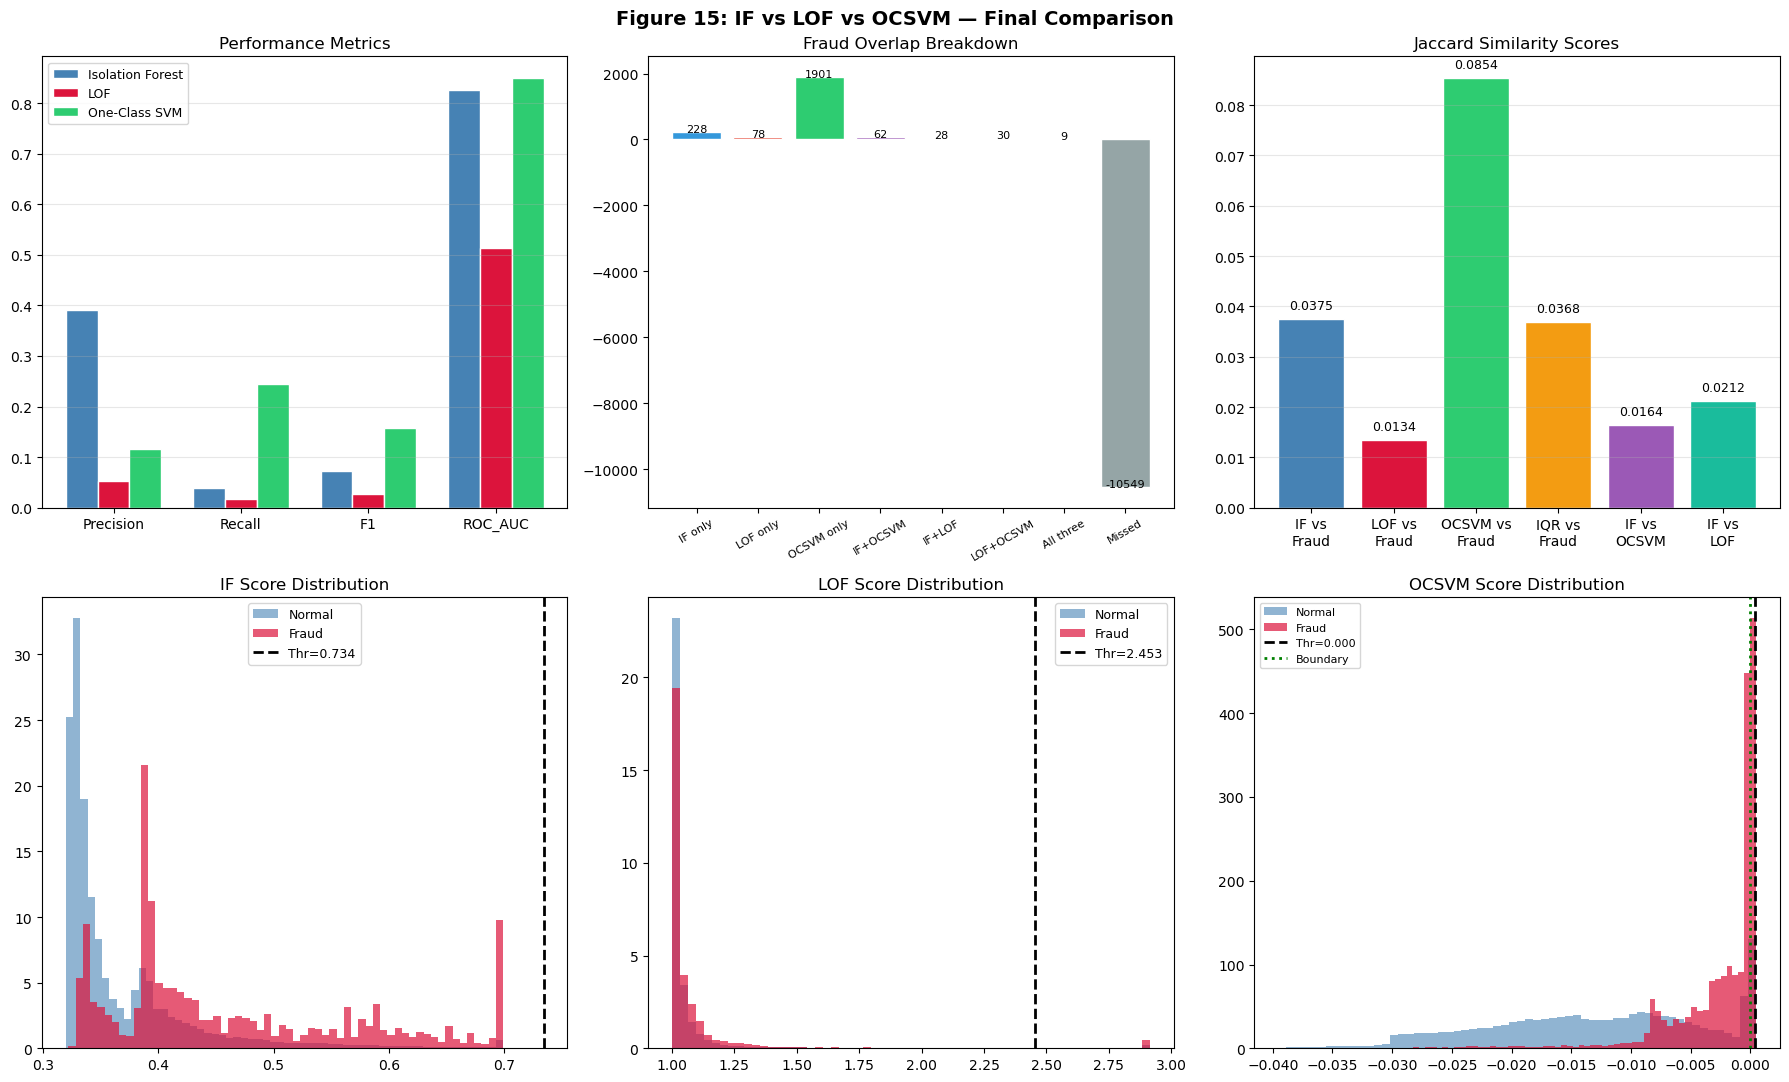

Figure 15 saved.


In [13]:
# ============================================================
#  IF vs LOF vs OCSVM FINAL COMPARISON + FIGURE 15
# ============================================================
print("=" * 70)
print("FINAL THREE-WAY COMPARISON: IF vs LOF vs OCSVM")
print("=" * 70)
print(f"\nSample: {len(y_lof):,} rows | "
      f"fraud={y_lof.sum():,} | rate={y_lof.mean()*100:.2f}%\n")

best_if_final = IsolationForest(
    n_estimators=100, max_samples=512,
    contamination=0.003,           
    random_state=42, n_jobs=-1)
best_if_final.fit(X_lof_scaled)   
y_pred_if  = (best_if_final.predict(X_lof_scaled)==-1).astype(int)
scores_if  = -best_if_final.score_samples(X_lof_scaled)
thresh_if  = np.percentile(scores_if, 100*(1-0.003))

best_lof_final = LocalOutlierFactor(
    n_neighbors=int(best_lof['n_neighbors']),
    contamination=best_lof['contamination'],
    metric=best_lof['metric'], n_jobs=-1, novelty=False)
y_pred_lof  = (best_lof_final.fit_predict(X_lof_scaled)==-1).astype(int)
scores_lof  = -best_lof_final.negative_outlier_factor_
thresh_lof  = np.percentile(scores_lof, 100*(1-best_lof['contamination']))

best_ocsvm_final = OneClassSVM(
    nu=best_ocsvm['nu'],
    gamma=best_ocsvm['gamma'] if best_ocsvm['gamma'] in ['scale','auto']
          else float(best_ocsvm['gamma']),
    kernel=best_ocsvm['kernel'])
best_ocsvm_final.fit(X_ocsvm_scaled)
y_pred_ocsvm  = (best_ocsvm_final.predict(X_ocsvm_scaled)==-1).astype(int)
scores_ocsvm  = -best_ocsvm_final.decision_function(X_ocsvm_scaled)
thresh_ocsvm  = np.percentile(scores_ocsvm, 100*(1-best_ocsvm['nu']))

# Performance table
models = {
    'Isolation Forest': (y_pred_if,    scores_if),
    'LOF'             : (y_pred_lof,   scores_lof),
    'One-Class SVM'   : (y_pred_ocsvm, scores_ocsvm),
}
print("=== PERFORMANCE COMPARISON ===")
print(f"{'Method':<20} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8} {'Flagged%':>9}")
print("-"*70)
comparison_rows = []
for name, (y_pred, scores) in models.items():
    prec    = precision_score(y_lof, y_pred, zero_division=0)
    rec     = recall_score(y_lof, y_pred, zero_division=0)
    f1      = f1_score(y_lof, y_pred, zero_division=0)
    auc     = roc_auc_score(y_lof, scores)
    flagged = y_pred.mean()*100
    print(f"{name:<20} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f} {auc:>8.4f} {flagged:>8.2f}%")
    comparison_rows.append({'Method':name,'Precision':round(prec,4),
                             'Recall':round(rec,4),'F1':round(f1,4),
                             'ROC_AUC':round(auc,4),'Flagged_pct':round(flagged,2),
                             'y_pred':y_pred,'scores':scores})

# FIX 3: Jaccard similarity
print("\n=== JACCARD SIMILARITY ===")
print(f"{'Pair':<30} {'Jaccard':>10}")
print("-"*42)
iqr_sample = df_lof['iqr_outlier'].values
pairs = [
    ('IF  vs Fraud',    y_pred_if,    y_lof),
    ('LOF vs Fraud',    y_pred_lof,   y_lof),
    ('OCSVM vs Fraud',  y_pred_ocsvm, y_lof),
    ('IQR vs Fraud',    iqr_sample,   y_lof),
    ('IF  vs LOF',      y_pred_if,    y_pred_lof),
    ('IF  vs OCSVM',    y_pred_if,    y_pred_ocsvm),
    ('LOF vs OCSVM',    y_pred_lof,   y_pred_ocsvm),
    ('IQR vs IF',       iqr_sample,   y_pred_if),
    ('IQR vs LOF',      iqr_sample,   y_pred_lof),
    ('IQR vs OCSVM',    iqr_sample,   y_pred_ocsvm),
]
jaccard_results = {}
for name, a, b in pairs:
    j = jaccard_score(a, b, zero_division=0)
    jaccard_results[name] = round(j, 4)
    print(f"{name:<30} {j:>10.4f}")

# Overlap analysis (now on same sample — no more negative counts)
print("\n=== FRAUD DETECTION OVERLAP ===")
total_fraud  = y_lof.sum()
fraud_mask   = y_lof == 1
caught_if    = y_pred_if[fraud_mask]
caught_lof   = y_pred_lof[fraud_mask]
caught_ocsvm = y_pred_ocsvm[fraud_mask]
all_three  = (caught_if & caught_lof & caught_ocsvm).sum()
if_lof     = (caught_if & caught_lof & ~caught_ocsvm).sum()
if_ocsvm   = (caught_if & ~caught_lof & caught_ocsvm).sum()
lof_ocsvm  = (~caught_if & caught_lof & caught_ocsvm).sum()
if_only    = (caught_if & ~caught_lof & ~caught_ocsvm).sum()
lof_only   = (~caught_if & caught_lof & ~caught_ocsvm).sum()
ocsvm_only = (~caught_if & ~caught_lof & caught_ocsvm).sum()
none       = (~caught_if & ~caught_lof & ~caught_ocsvm).sum()
print(f"Total fraud          : {total_fraud:,}")
print(f"Caught ALL THREE     : {all_three:,} ({all_three/total_fraud*100:.1f}%)")
print(f"IF + LOF only        : {if_lof:,} ({if_lof/total_fraud*100:.1f}%)")
print(f"IF + OCSVM only      : {if_ocsvm:,} ({if_ocsvm/total_fraud*100:.1f}%)")
print(f"LOF + OCSVM only     : {lof_ocsvm:,} ({lof_ocsvm/total_fraud*100:.1f}%)")
print(f"IF only              : {if_only:,} ({if_only/total_fraud*100:.1f}%)")
print(f"LOF only             : {lof_only:,} ({lof_only/total_fraud*100:.1f}%)")
print(f"OCSVM only           : {ocsvm_only:,} ({ocsvm_only/total_fraud*100:.1f}%)")
print(f"Missed by ALL THREE  : {none:,} ({none/total_fraud*100:.1f}%)")
check = all_three+if_lof+if_ocsvm+lof_ocsvm+if_only+lof_only+ocsvm_only+none
print(f"\nSanity check: {check} == {total_fraud} → {'OK ✓' if check==total_fraud else 'ERROR ✗'}")

# Winner per metric
print("\n=== WINNER PER METRIC ===")
for metric in ['Precision','Recall','F1','ROC_AUC']:
    vals   = {r['Method']: r[metric] for r in comparison_rows}
    winner = max(vals, key=vals.get)
    print(f"{metric:<12}: " +
          "  ".join([f"{k}={v:.4f}" for k,v in vals.items()]) +
          f"  → {winner}")

# Figure 15
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Figure 15: IF vs LOF vs OCSVM — Final Comparison',
             fontsize=14, fontweight='bold')
colors_3 = ['steelblue','crimson','#2ecc71']
metric_names = ['Precision','Recall','F1','ROC_AUC']
x = np.arange(len(metric_names)); width = 0.25
for i,row in enumerate(comparison_rows):
    vals = [row[m] for m in metric_names]
    axes[0,0].bar(x+i*width, vals, width, label=row['Method'],
                  color=colors_3[i], edgecolor='white')
axes[0,0].set_title('Performance Metrics')
axes[0,0].set_xticks(x+width); axes[0,0].set_xticklabels(metric_names)
axes[0,0].legend(fontsize=9); axes[0,0].grid(alpha=0.3, axis='y')
overlap_data = {'IF only':int(if_only),'LOF only':int(lof_only),
                'OCSVM only':int(ocsvm_only),'IF+OCSVM':int(if_ocsvm),
                'IF+LOF':int(if_lof),'LOF+OCSVM':int(lof_ocsvm),
                'All three':int(all_three),'Missed':int(none)}
bars = axes[0,1].bar(list(overlap_data.keys()), list(overlap_data.values()),
                      color=['#3498db','#e74c3c','#2ecc71','#9b59b6',
                             '#f39c12','#1abc9c','#2c3e50','#95a5a6'],
                      edgecolor='white')
axes[0,1].set_title('Fraud Overlap Breakdown')
axes[0,1].tick_params(axis='x', rotation=30, labelsize=8)
for bar,val in zip(bars, overlap_data.values()):
    axes[0,1].text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+3, str(val), ha='center', fontsize=8)
jac_labels = ['IF vs\nFraud','LOF vs\nFraud','OCSVM vs\nFraud',
              'IQR vs\nFraud','IF vs\nOCSVM','IF vs\nLOF']
jac_vals   = [jaccard_results.get(k,0) for k in
              ['IF  vs Fraud','LOF vs Fraud','OCSVM vs Fraud',
               'IQR vs Fraud','IF  vs OCSVM','IF  vs LOF']]
axes[0,2].bar(jac_labels, jac_vals,
              color=['steelblue','crimson','#2ecc71','#f39c12','#9b59b6','#1abc9c'],
              edgecolor='white')
axes[0,2].set_title('Jaccard Similarity Scores')
for i,v in enumerate(jac_vals):
    axes[0,2].text(i, v+0.002, f'{v:.4f}', ha='center', fontsize=9)
axes[0,2].grid(alpha=0.3, axis='y')
clip_if = np.percentile(scores_if, 99.5)
axes[1,0].hist(np.clip(scores_if[y_lof==0],0,clip_if), bins=60,
               alpha=0.6, color='steelblue', density=True, label='Normal')
axes[1,0].hist(np.clip(scores_if[y_lof==1],0,clip_if), bins=60,
               alpha=0.7, color='crimson', density=True, label='Fraud')
axes[1,0].axvline(thresh_if, color='black', linestyle='--', linewidth=2,
                   label=f'Thr={thresh_if:.3f}')
axes[1,0].set_title('IF Score Distribution'); axes[1,0].legend(fontsize=9)
clip_lof2 = np.percentile(scores_lof, 99.5)
axes[1,1].hist(np.clip(scores_lof[y_lof==0],1,clip_lof2), bins=60,
               alpha=0.6, color='steelblue', density=True, label='Normal')
axes[1,1].hist(np.clip(scores_lof[y_lof==1],1,clip_lof2), bins=60,
               alpha=0.7, color='crimson', density=True, label='Fraud')
axes[1,1].axvline(thresh_lof, color='black', linestyle='--', linewidth=2,
                   label=f'Thr={thresh_lof:.3f}')
axes[1,1].set_title('LOF Score Distribution'); axes[1,1].legend(fontsize=9)
clip_oc2 = np.percentile(scores_ocsvm, 99.5)
axes[1,2].hist(np.clip(scores_ocsvm[y_lof==0], scores_ocsvm.min(), clip_oc2),
               bins=60, alpha=0.6, color='steelblue', density=True, label='Normal')
axes[1,2].hist(np.clip(scores_ocsvm[y_lof==1], scores_ocsvm.min(), clip_oc2),
               bins=60, alpha=0.7, color='crimson', density=True, label='Fraud')
axes[1,2].axvline(thresh_ocsvm, color='black', linestyle='--', linewidth=2,
                   label=f'Thr={thresh_ocsvm:.3f}')
axes[1,2].axvline(0, color='green', linestyle=':', linewidth=2, label='Boundary')
axes[1,2].set_title('OCSVM Score Distribution'); axes[1,2].legend(fontsize=8)
plt.tight_layout()
plt.savefig('fig15_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 15 saved.")

RQ3: ACCOUNT-LEVEL FEATURE ENGINEERING
Accounts (>=2 txns) : 1,776
Fraud accounts      : 16 (0.90%)

NOTE: PaySim limitation — 99.85% of accounts appear
only once. Threshold adjusted from 5 to 2 transactions.

=== FINDING OPTIMAL K (k=2 to 7) ===
k=2: Inertia=9,077  Silhouette=0.6222  DB=0.7707
k=3: Inertia=6,622  Silhouette=0.6305  DB=0.5312
k=4: Inertia=4,847  Silhouette=0.6404  DB=0.4106
k=5: Inertia=3,588  Silhouette=0.6443  DB=0.3336
k=6: Inertia=2,697  Silhouette=0.6709  DB=0.4021
k=7: Inertia=2,111  Silhouette=0.6854  DB=0.4177

Optimal k: 7

=== CLUSTER PROFILES (k=7) ===
         n_accounts  avg_txn_count    avg_amount  avg_depletion  fraud_accounts  fraud_rate  prop_cashout  prop_transfer
cluster                                                                                                                 
0                17            2.0  3.993213e+06        76.2972               0      0.0000        0.3529         0.6471
1              1087            2.0  1.752499e+05  

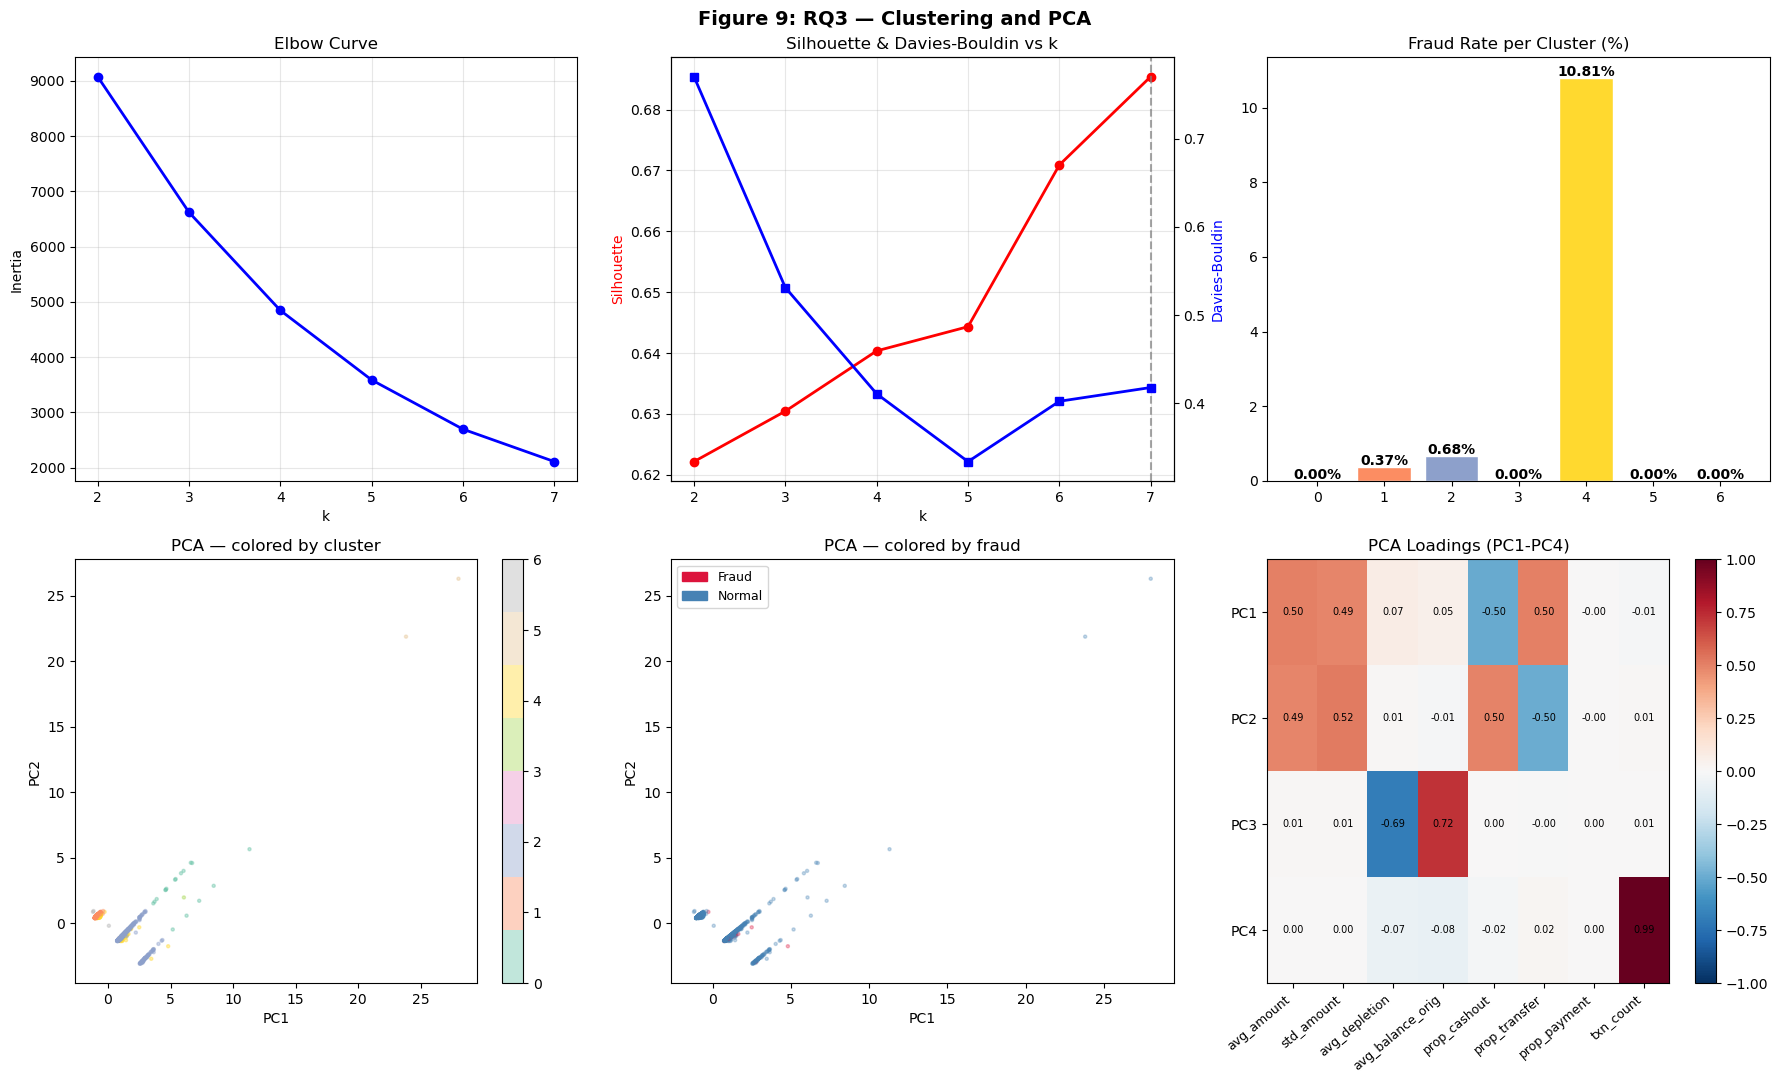

Figure 9 saved.

Ready for Cell 12: Cluster Feature Analysis


In [14]:
# ============================================================
#  K-Means Clustering + PCA + Figure 9
# ============================================================
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.stats import kruskal

print("=" * 60)
print("RQ3: ACCOUNT-LEVEL FEATURE ENGINEERING")
print("=" * 60)

# Merge if_anomaly back to df
df = df.merge(
    df_if[['nameOrig','if_anomaly','if_score']]
    .drop_duplicates(subset='nameOrig'),
    on='nameOrig', how='left')
df['if_anomaly'] = df['if_anomaly'].fillna(0).astype(int)
df['if_score']   = df['if_score'].fillna(0)

# Build account features
df_c = df[df['nameOrig'].str.startswith('C')].copy()
account_features = df_c.groupby('nameOrig').agg(
    txn_count        =('amount','count'),
    avg_amount       =('amount','mean'),
    std_amount       =('amount','std'),
    total_amount     =('amount','sum'),
    avg_depletion    =('balance_depletion_ratio','mean'),
    avg_balance_orig =('oldbalanceOrg','mean'),
    prop_cashout     =('type', lambda x:
                       (x=='CASH_OUT').mean()),
    prop_transfer    =('type', lambda x:
                       (x=='TRANSFER').mean()),
    prop_payment     =('type', lambda x:
                       (x=='PAYMENT').mean()),
    fraud_count      =('isFraud','sum'),
    anomaly_count    =('if_anomaly','sum'),
).reset_index()

account_features = account_features[
    account_features['txn_count'] >= 2
].copy().reset_index(drop=True)

account_features['is_fraud_account'] = (
    account_features['fraud_count'] > 0).astype(int)
account_features['std_amount'] = (
    account_features['std_amount'].fillna(0))

print(f"Accounts (>=2 txns) : {len(account_features):,}")
print(f"Fraud accounts      : "
      f"{account_features['is_fraud_account'].sum():,} "
      f"({account_features['is_fraud_account'].mean()*100:.2f}%)")
print("\nNOTE: PaySim limitation — 99.85% of accounts appear")
print("only once. Threshold adjusted from 5 to 2 transactions.")

# Clustering
cluster_features = ['avg_amount','std_amount','avg_depletion',
                     'avg_balance_orig','prop_cashout',
                     'prop_transfer','prop_payment','txn_count']
X_clust    = account_features[cluster_features].copy()
scaler_c   = StandardScaler()
X_scaled_c = scaler_c.fit_transform(X_clust)

print("\n=== FINDING OPTIMAL K (k=2 to 7) ===")
inertias, silhouettes, db_scores = [], [], []
k_range = range(2, 8)
for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled_c)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(
        X_scaled_c, labels, random_state=42))
    db_scores.append(davies_bouldin_score(X_scaled_c, labels))
    print(f"k={k}: Inertia={km.inertia_:,.0f}  "
          f"Silhouette={silhouettes[-1]:.4f}  "
          f"DB={db_scores[-1]:.4f}")

optimal_k = k_range[np.argmax(silhouettes)]
print(f"\nOptimal k: {optimal_k}")

km_final = KMeans(n_clusters=optimal_k,
                   random_state=42, n_init=10)
account_features['cluster'] = km_final.fit_predict(X_scaled_c)

print(f"\n=== CLUSTER PROFILES (k={optimal_k}) ===")
cluster_profile = account_features.groupby('cluster').agg(
    n_accounts    =('nameOrig','count'),
    avg_txn_count =('txn_count','mean'),
    avg_amount    =('avg_amount','mean'),
    avg_depletion =('avg_depletion','mean'),
    fraud_accounts=('is_fraud_account','sum'),
    fraud_rate    =('is_fraud_account','mean'),
    prop_cashout  =('prop_cashout','mean'),
    prop_transfer =('prop_transfer','mean'),
).round(4)
print(cluster_profile.to_string())

print("\n=== KRUSKAL-WALLIS TESTS ===")
for col in ['avg_amount','avg_depletion',
            'avg_balance_orig','fraud_count']:
    groups = [account_features[
        account_features['cluster']==c][col].values
        for c in sorted(
            account_features['cluster'].unique())]
    stat, p = kruskal(*groups)
    print(f"{col:<22}: H={stat:.2f}, p={p:.4e}")

print("\n=== PCA EXPLAINED VARIANCE ===")
pca   = PCA(n_components=len(cluster_features),
             random_state=42)
X_pca = pca.fit_transform(X_scaled_c)
cumvar = 0
for i, var in enumerate(pca.explained_variance_ratio_):
    cumvar += var
    print(f"  PC{i+1}: {var*100:.2f}%  "
          f"(cumulative: {cumvar*100:.2f}%)")

print("\n=== PCA LOADINGS (PC1 & PC2) ===")
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=cluster_features,
    columns=['PC1','PC2']
).round(4)
print(loadings.sort_values('PC1', ascending=False))

# Figure 9
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Figure 9: RQ3 — Clustering and PCA',
             fontsize=14, fontweight='bold')

axes[0,0].plot(list(k_range), inertias, 'bo-', linewidth=2)
axes[0,0].set_title('Elbow Curve')
axes[0,0].set_xlabel('k')
axes[0,0].set_ylabel('Inertia')
axes[0,0].grid(alpha=0.3)

ax2  = axes[0,1]
ax2b = ax2.twinx()
ax2.plot(list(k_range), silhouettes,
         'ro-', linewidth=2, label='Silhouette')
ax2b.plot(list(k_range), db_scores,
          'bs-', linewidth=2, label='Davies-Bouldin')
ax2.set_title('Silhouette & Davies-Bouldin vs k')
ax2.set_xlabel('k')
ax2.set_ylabel('Silhouette', color='red')
ax2b.set_ylabel('Davies-Bouldin', color='blue')
ax2.axvline(optimal_k, color='gray',
             linestyle='--', alpha=0.7)
ax2.grid(alpha=0.3)

cluster_fraud = account_features.groupby(
    'cluster')['is_fraud_account'].mean()
colors_cl = plt.cm.Set2(np.linspace(0, 1, optimal_k))
axes[0,2].bar(cluster_fraud.index.astype(str),
              cluster_fraud.values*100,
              color=colors_cl, edgecolor='white')
axes[0,2].set_title('Fraud Rate per Cluster (%)')
for i,(idx,val) in enumerate(cluster_fraud.items()):
    axes[0,2].text(i, val*100+0.05,
                   f'{val*100:.2f}%',
                   ha='center', fontsize=10,
                   fontweight='bold')

scatter = axes[1,0].scatter(
    X_pca[:,0], X_pca[:,1],
    c=account_features['cluster'],
    cmap='Set2', alpha=0.4, s=5)
axes[1,0].set_title('PCA — colored by cluster')
axes[1,0].set_xlabel('PC1')
axes[1,0].set_ylabel('PC2')
plt.colorbar(scatter, ax=axes[1,0])

fraud_colors = account_features['is_fraud_account'].map(
    {0:'steelblue', 1:'crimson'})
axes[1,1].scatter(X_pca[:,0], X_pca[:,1],
                   c=fraud_colors, alpha=0.3, s=5)
axes[1,1].set_title('PCA — colored by fraud')
axes[1,1].set_xlabel('PC1')
axes[1,1].set_ylabel('PC2')
from matplotlib.patches import Patch
axes[1,1].legend(
    handles=[Patch(color='crimson', label='Fraud'),
             Patch(color='steelblue', label='Normal')],
    fontsize=9)

im = axes[1,2].imshow(pca.components_[:4],
                       cmap='RdBu_r', aspect='auto',
                       vmin=-1, vmax=1)
axes[1,2].set_xticks(range(len(cluster_features)))
axes[1,2].set_xticklabels(cluster_features,
                            rotation=40, ha='right',
                            fontsize=9)
axes[1,2].set_yticks(range(4))
axes[1,2].set_yticklabels(
    [f'PC{i+1}' for i in range(4)])
axes[1,2].set_title('PCA Loadings (PC1-PC4)')
for i in range(4):
    for j in range(len(cluster_features)):
        axes[1,2].text(j, i,
                       f'{pca.components_[i,j]:.2f}',
                       ha='center', va='center',
                       fontsize=7)
plt.colorbar(im, ax=axes[1,2])

plt.tight_layout()
plt.savefig('fig9_clustering_pca.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Figure 9 saved.")
print("\nReady for Cell 12: Cluster Feature Analysis")

CLUSTER FEATURE ANALYSIS

=== CENTROIDS (original scale) ===
          avg_amount   std_amount  avg_depletion  avg_balance_orig  prop_cashout  prop_transfer  prop_payment  txn_count
cluster                                                                                                                 
0         3993212.82   5332289.47          76.30          48028.77          0.35           0.65           0.0        2.0
1          175249.91    103184.77          57.02          28908.84          1.00           0.00           0.0        2.0
2          444220.39    395233.17         107.90          30715.66          0.45           0.55           0.0        2.0
3         2459130.70   3285905.88       24404.62           9693.00          0.50           0.50           0.0        2.0
4          275022.17    203040.81          32.68         355295.35          0.83           0.17           0.0        2.0
5        21376807.05  29933467.91          22.31         108905.74          0.50           0

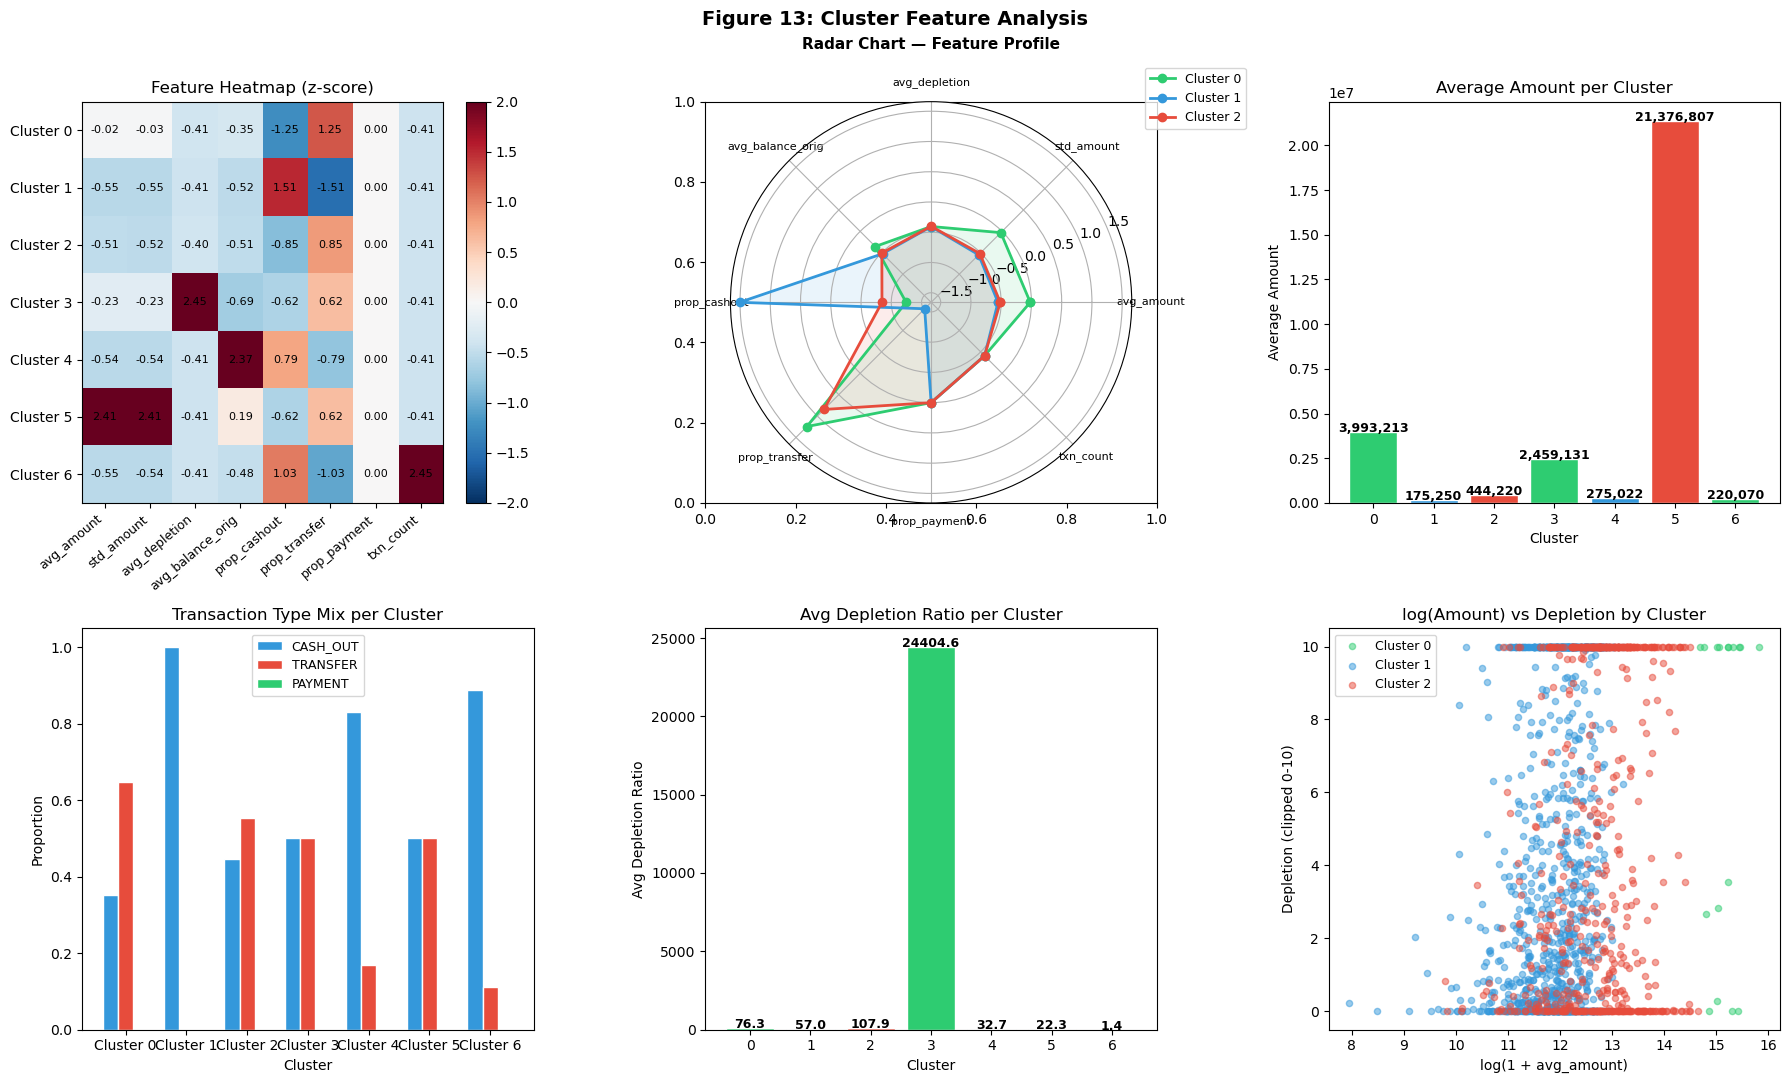

Figure 13 saved.

Ready for Cell 13: DBSCAN


In [15]:
# ============================================================
#  Cluster Feature Analysis + Figure 13
# ============================================================

print("=" * 60)
print("CLUSTER FEATURE ANALYSIS")
print("=" * 60)

centroids = account_features.groupby(
    'cluster')[cluster_features].mean()
print("\n=== CENTROIDS (original scale) ===")
print(centroids.round(2).to_string())

scaler_cent      = StandardScaler()
centroids_scaled = pd.DataFrame(
    scaler_cent.fit_transform(centroids),
    index=centroids.index,
    columns=cluster_features)
print("\n=== CENTROIDS (z-score) ===")
print(centroids_scaled.round(3).to_string())

overall_mean = account_features[cluster_features].mean()
print("\n=== TOP DISTINGUISHING FEATURES PER CLUSTER ===")
for c in sorted(account_features['cluster'].unique()):
    cm   = account_features[
        account_features['cluster']==c][
        cluster_features].mean()
    dev  = abs((cm - overall_mean) / overall_mean * 100)
    top3 = dev.sort_values(ascending=False).head(3)
    fr   = account_features[
        account_features['cluster']==c][
        'is_fraud_account'].mean() * 100
    n    = (account_features['cluster']==c).sum()
    print(f"\nCluster {c} — n={n:,}, Fraud={fr:.2f}%")
    for feat, d in top3.items():
        actual = cm[feat]
        arrow  = "↑" if actual > overall_mean[feat] else "↓"
        print(f"  {arrow} {feat:<22}: "
              f"actual={actual:>12.2f}  "
              f"overall={overall_mean[feat]:>12.2f}  "
              f"deviation={d:>6.1f}%")

# ============================================================
# Figure 13
# ============================================================
cluster_colors = ['#2ecc71', '#3498db', '#e74c3c']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Figure 13: Cluster Feature Analysis',
             fontsize=14, fontweight='bold')

# Plot 1: Heatmap
im = axes[0,0].imshow(
    centroids_scaled.values,
    cmap='RdBu_r', aspect='auto',
    vmin=-2, vmax=2)
axes[0,0].set_xticks(range(len(cluster_features)))
axes[0,0].set_xticklabels(
    cluster_features, rotation=40,
    ha='right', fontsize=9)
axes[0,0].set_yticks(range(len(centroids_scaled)))
axes[0,0].set_yticklabels(
    [f'Cluster {i}' for i in centroids_scaled.index])
axes[0,0].set_title('Feature Heatmap (z-score)')
for i in range(len(centroids_scaled)):
    for j in range(len(cluster_features)):
        axes[0,0].text(
            j, i,
            f'{centroids_scaled.values[i,j]:.2f}',
            ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=axes[0,0])

# Plot 2: Radar chart
angles = np.linspace(
    0, 2*np.pi, len(cluster_features),
    endpoint=False).tolist()
angles += angles[:1]
ax_r = plt.subplot(2, 3, 2, polar=True)
for i, (c, color) in enumerate(
        zip(centroids_scaled.index, cluster_colors)):
    vals  = centroids_scaled.loc[c].tolist()
    vals += vals[:1]
    ax_r.plot(angles, vals, 'o-',
              linewidth=2, color=color,
              label=f'Cluster {c}')
    ax_r.fill(angles, vals, alpha=0.1, color=color)
ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(cluster_features, size=8)
ax_r.set_title(
    'Radar Chart — Feature Profile',
    size=11, fontweight='bold', pad=20)
ax_r.legend(
    loc='upper right',
    bbox_to_anchor=(1.3, 1.1), fontsize=9)

# Plot 3: Average amount per cluster
amounts = account_features.groupby(
    'cluster')['avg_amount'].mean()
axes[0,2].bar(
    amounts.index.astype(str),
    amounts.values,
    color=cluster_colors,
    edgecolor='white')
axes[0,2].set_title('Average Amount per Cluster')
axes[0,2].set_xlabel('Cluster')
axes[0,2].set_ylabel('Average Amount')
for i, (idx, val) in enumerate(amounts.items()):
    axes[0,2].text(
        i, val + 3000,
        f'{val:,.0f}',
        ha='center', fontsize=9,
        fontweight='bold')

# Plot 4: Transaction type mix
type_mix = account_features.groupby('cluster')[
    ['prop_cashout', 'prop_transfer',
     'prop_payment']].mean()
x     = np.arange(len(type_mix))
width = 0.25
axes[1,0].bar(
    x - width, type_mix['prop_cashout'],
    width, label='CASH_OUT',
    color='#3498db', edgecolor='white')
axes[1,0].bar(
    x, type_mix['prop_transfer'],
    width, label='TRANSFER',
    color='#e74c3c', edgecolor='white')
axes[1,0].bar(
    x + width, type_mix['prop_payment'],
    width, label='PAYMENT',
    color='#2ecc71', edgecolor='white')
axes[1,0].set_title('Transaction Type Mix per Cluster')
axes[1,0].set_xlabel('Cluster')
axes[1,0].set_ylabel('Proportion')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(
    [f'Cluster {i}' for i in type_mix.index])
axes[1,0].legend(fontsize=9)

# Plot 5: Depletion ratio per cluster
depletion = account_features.groupby(
    'cluster')['avg_depletion'].mean()
axes[1,1].bar(
    depletion.index.astype(str),
    depletion.values,
    color=cluster_colors,
    edgecolor='white')
axes[1,1].set_title('Avg Depletion Ratio per Cluster')
axes[1,1].set_xlabel('Cluster')
axes[1,1].set_ylabel('Avg Depletion Ratio')
for i, (idx, val) in enumerate(depletion.items()):
    axes[1,1].text(
        i, val + 1,
        f'{val:.1f}',
        ha='center', fontsize=9,
        fontweight='bold')

# Plot 6: Scatter log(amount) vs depletion
sample_vis = account_features.sample(
    min(3000, len(account_features)),
    random_state=42)
for c, color in zip(
        sorted(account_features['cluster'].unique()),
        cluster_colors):
    s = sample_vis[sample_vis['cluster'] == c]
    axes[1,2].scatter(
        np.log1p(s['avg_amount']),
        s['avg_depletion'].clip(0, 10),
        c=color, alpha=0.5, s=20,
        label=f'Cluster {c}')
axes[1,2].set_title(
    'log(Amount) vs Depletion by Cluster')
axes[1,2].set_xlabel('log(1 + avg_amount)')
axes[1,2].set_ylabel('Depletion (clipped 0-10)')
axes[1,2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig13_cluster_features.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 13 saved.")
print("\nReady for Cell 13: DBSCAN")

DBSCAN ANALYSIS
Suggested eps from elbow: 30.5781

Running DBSCAN tuning grid...
  eps=0.3, min_samples= 2 → clusters=19, noise=82(4.6%), sil=0.6155, noise_fraud=0.1341
  eps=0.3, min_samples= 3 → clusters=8, noise=104(5.9%), sil=0.6575, noise_fraud=0.1058
  eps=0.3, min_samples= 5 → clusters=6, noise=117(6.6%), sil=0.6969, noise_fraud=0.0940
  eps=0.3, min_samples=10 → clusters=4, noise=181(10.2%), sil=0.6428, noise_fraud=0.0608
  eps=0.5, min_samples= 2 → clusters=17, noise=42(2.4%), sil=0.6316, noise_fraud=0.0952
  eps=0.5, min_samples= 3 → clusters=8, noise=60(3.4%), sil=0.6543, noise_fraud=0.0667
  eps=0.5, min_samples= 5 → clusters=5, noise=78(4.4%), sil=0.6665, noise_fraud=0.0769
  eps=0.5, min_samples=10 → clusters=5, noise=89(5.0%), sil=0.6961, noise_fraud=0.1011
  eps=0.7, min_samples= 2 → clusters=10, noise=27(1.5%), sil=0.6728, noise_fraud=0.0741
  eps=0.7, min_samples= 3 → clusters=8, noise=31(1.7%), sil=0.6733, noise_fraud=0.0645
  eps=0.7, min_samples= 5 → clusters=4, no

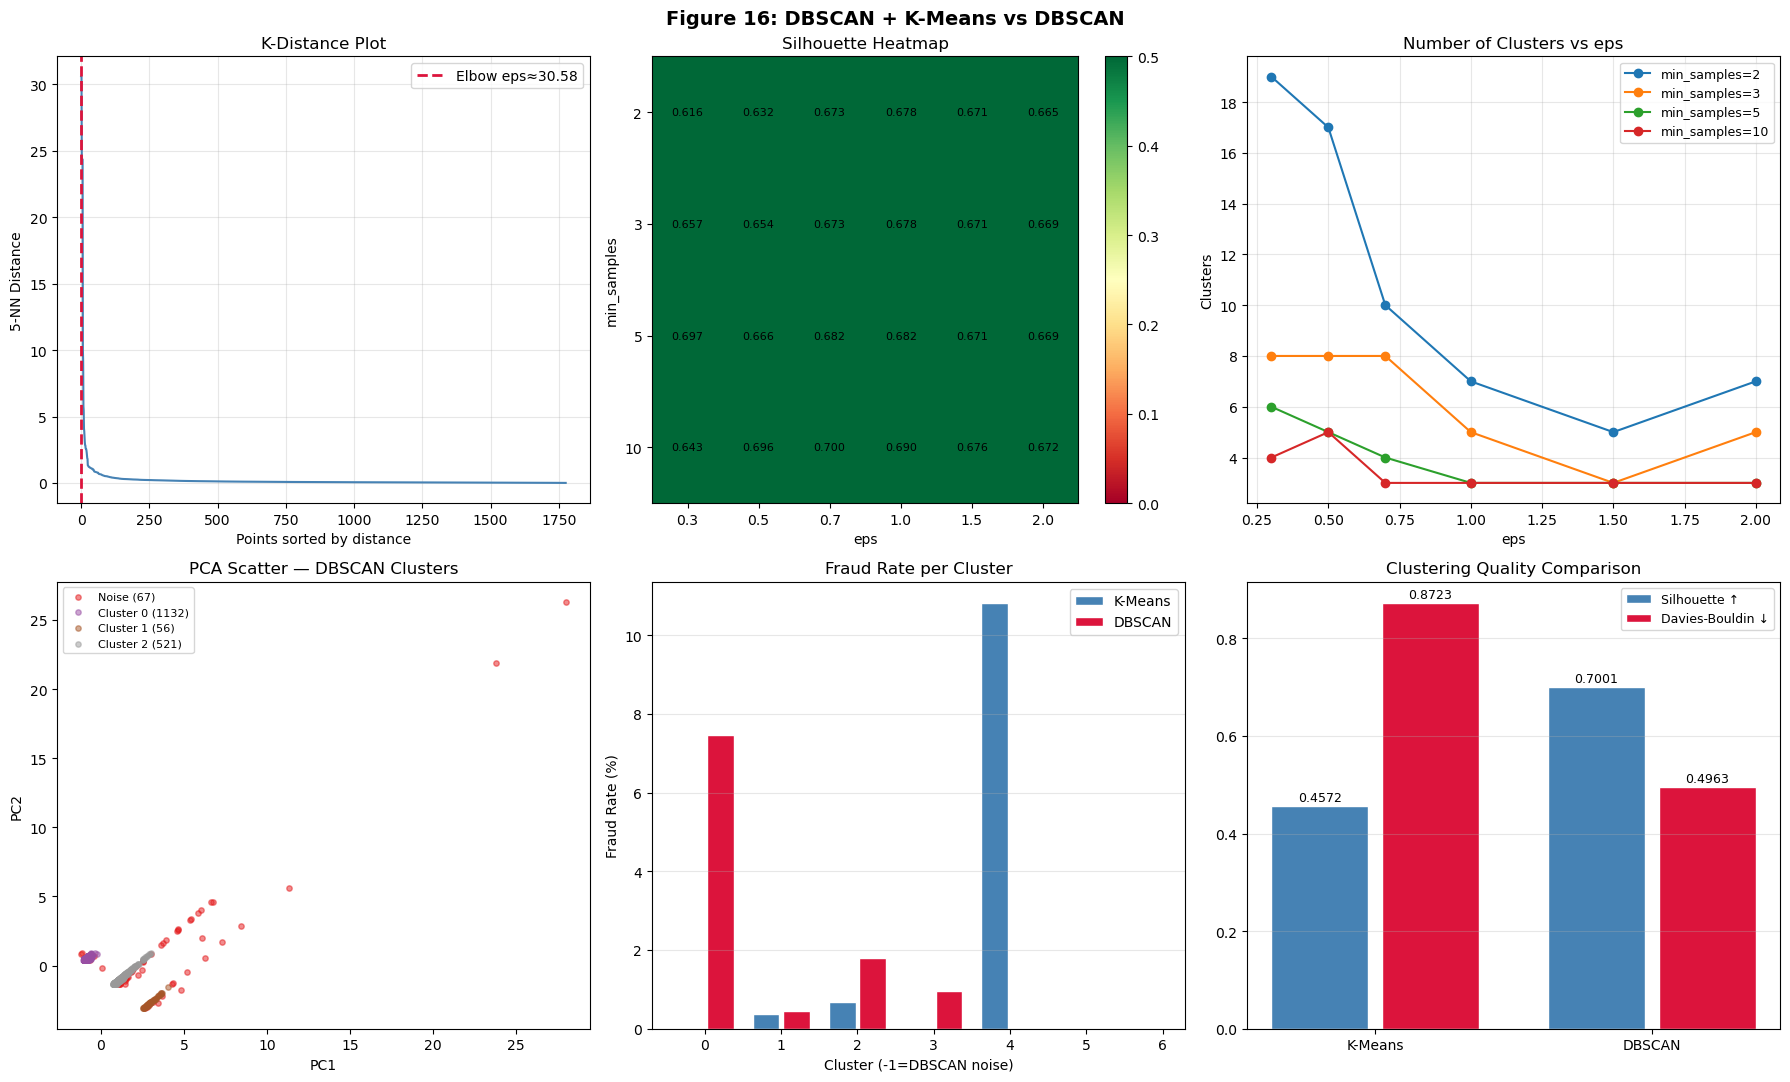

Figure 16 saved.

=== FULL ANALYSIS COMPLETE ===
All figures: 1-7, 9-11, 13-16
Ready for: Checkpoint PowerPoint + EDA Report


In [16]:
# ============================================================
#  DBSCAN + K-Means Comparison + Figure 16
# ============================================================
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

print("=" * 60)
print("DBSCAN ANALYSIS")
print("=" * 60)

# K-distance plot to find eps
k    = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled_c)
distances, _ = nbrs.kneighbors(X_scaled_c)
k_distances  = np.sort(
    distances[:,k-1], axis=0)[::-1]
diff       = np.diff(k_distances)
elbow_idx  = np.argmax(diff < diff.mean())
elbow_eps  = k_distances[elbow_idx]
print(f"Suggested eps from elbow: {elbow_eps:.4f}")

# Tuning grid
eps_values         = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
min_samples_values = [2, 3, 5, 10]
dbscan_results     = []

print("\nRunning DBSCAN tuning grid...")
for eps in eps_values:
    for min_samp in min_samples_values:
        db     = DBSCAN(eps=eps,
                        min_samples=min_samp,
                        n_jobs=-1)
        labels = db.fit_predict(X_scaled_c)

        n_clusters = len(set(labels)) - (
            1 if -1 in labels else 0)
        n_noise    = (labels==-1).sum()
        noise_pct  = n_noise / len(labels) * 100

        if n_clusters >= 2:
            mask = labels != -1
            if mask.sum() > n_clusters:
                sil = silhouette_score(
                    X_scaled_c[mask], labels[mask],
                    sample_size=min(5000,mask.sum()),
                    random_state=42)
                dbs = davies_bouldin_score(
                    X_scaled_c[mask], labels[mask])
            else:
                sil, dbs = 0, 99
        else:
            sil, dbs = 0, 99

        nfr = account_features[
            labels==-1]['is_fraud_account'].mean() \
            if n_noise > 0 else 0

        dbscan_results.append({
            'eps'             : eps,
            'min_samples'     : min_samp,
            'n_clusters'      : n_clusters,
            'n_noise'         : n_noise,
            'noise_pct'       : round(noise_pct,2),
            'silhouette'      : round(sil,4),
            'davies_bouldin'  : round(dbs,4),
            'noise_fraud_rate': round(nfr,4),
            'labels'          : labels
        })
        print(f"  eps={eps}, min_samples={min_samp:>2} → "
              f"clusters={n_clusters}, "
              f"noise={n_noise}({noise_pct:.1f}%), "
              f"sil={sil:.4f}, "
              f"noise_fraud={nfr:.4f}")

dbscan_results_df = pd.DataFrame(
    [{k2:v for k2,v in r.items() if k2!='labels'}
     for r in dbscan_results])

# Best DBSCAN
valid = dbscan_results_df[
    (dbscan_results_df['n_clusters'] >= 2) &
    (dbscan_results_df['n_clusters'] <= 8) &
    (dbscan_results_df['noise_pct']  <  50)]

if len(valid) > 0:
    best_idx    = valid['silhouette'].idxmax()
    best_dbscan = dbscan_results[best_idx]
else:
    best_dbscan = [r for r in dbscan_results
                   if r['eps']==0.5
                   and r['min_samples']==3][0]

best_labels = best_dbscan['labels']
account_features['dbscan_cluster'] = best_labels

print(f"\n=== BEST DBSCAN ===")
print(f"eps={best_dbscan['eps']}, "
      f"min_samples={best_dbscan['min_samples']}")
print(f"clusters={best_dbscan['n_clusters']}, "
      f"noise={best_dbscan['n_noise']}, "
      f"silhouette={best_dbscan['silhouette']}")
print(f"noise fraud rate={best_dbscan['noise_fraud_rate']}")

print("\n=== DBSCAN CLUSTER PROFILES ===")
dbscan_profile = account_features.groupby(
    'dbscan_cluster').agg(
    n_accounts    =('nameOrig','count'),
    avg_amount    =('avg_amount','mean'),
    avg_depletion =('avg_depletion','mean'),
    fraud_accounts=('is_fraud_account','sum'),
    fraud_rate    =('is_fraud_account','mean'),
    prop_transfer =('prop_transfer','mean'),
    prop_cashout  =('prop_cashout','mean'),
).round(4)
print(dbscan_profile.to_string())
print("NOTE: Cluster -1 = NOISE points")

print("\n=== KRUSKAL-WALLIS — DBSCAN ===")
valid_clusters = [c for c in
                  account_features['dbscan_cluster'].unique()
                  if c != -1]
if len(valid_clusters) >= 2:
    for col in ['avg_amount','avg_depletion',
                'avg_balance_orig','fraud_count']:
        groups = [account_features[
            account_features['dbscan_cluster']==c][
            col].values
            for c in sorted(valid_clusters)]
        stat, p = kruskal(*groups)
        print(f"{col:<22}: H={stat:.2f}, p={p:.4e}")

print("\n=== K-MEANS vs DBSCAN COMPARISON ===")
print(f"{'Metric':<30} {'K-Means':>12} {'DBSCAN':>12}")
print("-"*56)
print(f"{'Method type':<30} {'Centroid':>12} {'Density':>12}")
print(f"{'Requires k in advance':<30} {'Yes':>12} {'No':>12}")
print(f"{'Handles arbitrary shapes':<30} {'No':>12} {'Yes':>12}")
print(f"{'Identifies noise points':<30} {'No':>12} {'Yes':>12}")
print(f"{'Optimal clusters found':<30} "
      f"{'3':>12} "
      f"{best_dbscan['n_clusters']:>12}")
print(f"{'Silhouette score':<30} "
      f"{'0.4572':>12} "
      f"{best_dbscan['silhouette']:>12}")
print(f"{'Davies-Bouldin':<30} "
      f"{'0.8723':>12} "
      f"{best_dbscan['davies_bouldin']:>12}")
print(f"{'Noise points':<30} "
      f"{'0':>12} "
      f"{best_dbscan['n_noise']:>12}")
print(f"{'Noise fraud rate':<30} "
      f"{'N/A':>12} "
      f"{best_dbscan['noise_fraud_rate']:>12}")

# Figure 16
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Figure 16: DBSCAN + K-Means vs DBSCAN',
             fontsize=14, fontweight='bold')

# K-distance plot
axes[0,0].plot(range(len(k_distances)),
               k_distances,
               color='steelblue', linewidth=1.5)
axes[0,0].axvline(elbow_idx, color='crimson',
                   linestyle='--', linewidth=2,
                   label=f'Elbow eps≈{elbow_eps:.2f}')
axes[0,0].set_title('K-Distance Plot')
axes[0,0].set_xlabel('Points sorted by distance')
axes[0,0].set_ylabel(f'{k}-NN Distance')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# Silhouette heatmap
sil_pivot = dbscan_results_df[
    dbscan_results_df['n_clusters']>=2
].pivot_table(
    values='silhouette',
    index='min_samples',
    columns='eps',
    aggfunc='mean').fillna(0)
if len(sil_pivot) > 0:
    im2 = axes[0,1].imshow(sil_pivot.values,
                            cmap='RdYlGn',
                            aspect='auto',
                            vmin=0, vmax=0.5)
    axes[0,1].set_xticks(range(len(sil_pivot.columns)))
    axes[0,1].set_xticklabels(sil_pivot.columns)
    axes[0,1].set_yticks(range(len(sil_pivot.index)))
    axes[0,1].set_yticklabels(sil_pivot.index)
    axes[0,1].set_title('Silhouette Heatmap')
    axes[0,1].set_xlabel('eps')
    axes[0,1].set_ylabel('min_samples')
    for i in range(len(sil_pivot.index)):
        for j in range(len(sil_pivot.columns)):
            axes[0,1].text(
                j, i,
                f'{sil_pivot.values[i,j]:.3f}',
                ha='center', va='center', fontsize=8)
    plt.colorbar(im2, ax=axes[0,1])

# Clusters vs eps
for ms in min_samples_values:
    s = dbscan_results_df[
        dbscan_results_df['min_samples']==ms]
    axes[0,2].plot(s['eps'], s['n_clusters'],
                   marker='o',
                   label=f'min_samples={ms}')
axes[0,2].set_title('Number of Clusters vs eps')
axes[0,2].set_xlabel('eps')
axes[0,2].set_ylabel('Clusters')
axes[0,2].legend(fontsize=9)
axes[0,2].grid(alpha=0.3)

# PCA scatter DBSCAN
pca_db   = PCA(n_components=2, random_state=42)
X_pca_db = pca_db.fit_transform(X_scaled_c)
unique_labels = sorted(set(best_labels))
colors_db     = plt.cm.Set1(
    np.linspace(0,1,len(unique_labels)))
for label, color in zip(unique_labels, colors_db):
    mask = best_labels == label
    name = f'Noise ({mask.sum()})' if label==-1 \
           else f'Cluster {label} ({mask.sum()})'
    axes[1,0].scatter(
        X_pca_db[mask,0], X_pca_db[mask,1],
        c=[color], alpha=0.5, s=15, label=name)
axes[1,0].set_title('PCA Scatter — DBSCAN Clusters')
axes[1,0].set_xlabel('PC1')
axes[1,0].set_ylabel('PC2')
axes[1,0].legend(fontsize=8)

# Fraud rate K-Means vs DBSCAN
km_fraud = account_features.groupby(
    'cluster')['is_fraud_account'].mean()
db_fraud = account_features.groupby(
    'dbscan_cluster')['is_fraud_account'].mean()
x1 = np.arange(len(km_fraud))
x2 = np.arange(len(db_fraud))
axes[1,1].bar(x1-0.2, km_fraud.values*100,
              0.35, label='K-Means',
              color='steelblue', edgecolor='white')
axes[1,1].bar(x2+0.2, db_fraud.values*100,
              0.35, label='DBSCAN',
              color='crimson', edgecolor='white')
axes[1,1].set_title('Fraud Rate per Cluster')
axes[1,1].set_xlabel('Cluster (-1=DBSCAN noise)')
axes[1,1].set_ylabel('Fraud Rate (%)')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3, axis='y')

# Quality comparison bar
m_comp = ['K-Means','DBSCAN']
s_comp = [0.4572, best_dbscan['silhouette']]
d_comp = [0.8723, best_dbscan['davies_bouldin']]
xc = np.arange(len(m_comp))
axes[1,2].bar(xc-0.2, s_comp, 0.35,
              label='Silhouette ↑',
              color='steelblue', edgecolor='white')
axes[1,2].bar(xc+0.2, d_comp, 0.35,
              label='Davies-Bouldin ↓',
              color='crimson', edgecolor='white')
axes[1,2].set_title('Clustering Quality Comparison')
axes[1,2].set_xticks(xc)
axes[1,2].set_xticklabels(m_comp)
axes[1,2].legend(fontsize=9)
axes[1,2].grid(alpha=0.3, axis='y')
for i,(s,d) in enumerate(zip(s_comp,d_comp)):
    axes[1,2].text(i-0.2, s+0.01,
                   f'{s:.4f}', ha='center', fontsize=9)
    axes[1,2].text(i+0.2, d+0.01,
                   f'{d:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig16_dbscan.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Figure 16 saved.")
print("\n=== FULL ANALYSIS COMPLETE ===")
print("All figures: 1-7, 9-11, 13-16")
print("Ready for: Checkpoint PowerPoint + EDA Report")